In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
import math
import warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score, euclidean_distances
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from tensorflow.keras.layers import (Layer, Input, LSTM, Dropout, Dense, Activation, LeakyReLU, Conv1D, MaxPooling1D, Flatten, Add, Concatenate)
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop, Ftrl, Adadelta, Adagrad, SGD
from tensorflow.keras.optimizers.legacy import Adam as LegacyAdam, RMSprop as LegacyRMSprop
import tensorflow as tf
import seaborn as sns
# 데이터 전처리와 모델 학습에 사용할 여러 함수 및 라이브러리들을 불러옵니다.
# pandas, numpy는 데이터 처리를, tensorflow는 모델 빌드 및 학습을, sklearn은 평가와 교차 검증을 위해 사용합니다.
# yfinance를 통해 주식 데이터를 수집하고, datetime은 날짜 및 시간 처리를 위해 사용합니다.

# 주요 라이브러리 목록
# - pandas, numpy: 데이터 프레임 및 수치 계산
# - matplotlib, seaborn: 데이터 시각화
# - yfinance: 주식 데이터 수집
# - tensorflow.keras: 딥러닝 모델 빌드 및 학습
# - sklearn: 교차 검증 및 성능 평가 도구

# 딥러닝 레이어 및 모델 설정 (LSTM, Dense, Dropout, Conv1D, MaxPooling1D 등 다양한 레이어 사용 가능)
# 옵티마이저 설정 (Adam, RMSprop, SGD 등 다양한 옵티마이저 선택 가능)
# 모델 평가를 위한 혼동 행렬, ROC 커브, F1 스코어 등의 성능 지표 사용

In [2]:
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#피쳐 추가

In [4]:
moving_average_periods = [5, 10, 20, 60, 120]
#macd를 위함
short_period = 12  # 단기 이동 평균 기간
long_period = 26   # 장기 이동 평균 기간
std_period = 5
momentum_period = 14

def DEMA(data, period):
    ema = data.ewm(span=period, adjust=False).mean()
    dema = 2 * ema - ema.ewm(span=period, adjust=False).mean()
    return dema

def TEMA(data, period):
    ema = data.ewm(span=period, adjust=False).mean()
    ema_ema = ema.ewm(span=period, adjust=False).mean()
    tema = 3 * ema - 3 * ema_ema + ema_ema.ewm(span=period, adjust=False).mean()
    return tema


# 주가 지표 계산 함수
def calculate_technical_indicators(df):
    for period in moving_average_periods:
        df[f'MA{period}'] = df.groupby('Symbol')['ClosePrice'].transform(lambda x: x.rolling(period).mean())
        df[f'Grad{period}'] = df.groupby('Symbol')[f'MA{period}'].transform(lambda x: np.gradient(x))
        df[f'VMA{period}'] = df.groupby('Symbol')['Volume'].transform(lambda x: x.rolling(period).mean())
        df[f'VGrad{period}'] = df.groupby('Symbol')[f'VMA{period}'].transform(lambda x: np.gradient(x))
        df[f'Dis{period}'] = (df['ClosePrice'] / df[f'MA{period}']) * 100
        df[f'Div{period}'] = df['ClosePrice'] - df[f'MA{period}']
        df[f'VDis{period}'] = (df['Volume'] / df[f'VMA{period}']) * 100
        df[f'VDiv{period}'] = df['Volume'] - df[f'VMA{period}']
        df[f'EMA{period}'] = df.groupby('Symbol')['ClosePrice'].transform(lambda x: x.ewm(span=period, adjust=False).mean())
        df[f'DEMA{period}'] = df.groupby('Symbol')['ClosePrice'].transform(lambda x: DEMA(x, period))
        df[f'TEMA{period}'] = df.groupby('Symbol')['ClosePrice'].transform(lambda x: TEMA(x, period))
        df[f'VWAP{period}'] = (df['ClosePrice'] * df['Volume']).cumsum() / df['Volume'].cumsum()
        df[f'ROC{period}'] = (df['ClosePrice'] - df['ClosePrice'].shift(period)) / df['ClosePrice'].shift(period) * 100



    df['High-Low'] = df['HighPrice'] - df['LowPrice']
    df['High-PrevClose'] = abs(df['HighPrice'] - df['ClosePrice'].shift(1))
    df['Low-PrevClose'] = abs(df['LowPrice'].shift(1) - df['ClosePrice'])
    df['TR'] = df[['High-Low', 'High-PrevClose', 'Low-PrevClose']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=std_period).mean()

    df['Gain'] = df['ChangeRatio'][df['ChangeRatio'] > 0]
    df['Loss'] = -df['ChangeRatio'][df['ChangeRatio'] < 0]
    average_gain = df['Gain'][:std_period].mean()
    average_loss = df['Loss'][:std_period].mean()
    relative_strength = average_gain / average_loss
    rsi = 100 - (100 / (1 + relative_strength))
    df['RSI'] = rsi

    df['ShortEMA'] = df['ClosePrice'].ewm(span=short_period, adjust=False).mean()
    df['LongEMA'] = df['ClosePrice'].ewm(span=long_period, adjust=False).mean()
    df['MACD'] = df['ShortEMA'] - df['LongEMA']
    signal_period = 9
    df['SignalLine'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()
    df['MACD_Histogram'] = df['MACD'] - df['SignalLine']

    df['StdDev'] = df['ClosePrice'].rolling(window=20).std()
    df['UpperBand'] = df['MA20'] + (2 * df['StdDev'])
    df['LowerBand'] = df['MA20'] - (2 * df['StdDev'])

    # df['UpMove'] = df['HighPrice'] - df['HighPrice'].shift(1)
    # df['DownMove'] = df['LowPrice'].shift(1) - df['LowPrice']
    # df['PlusDM'] = (df['UpMove'] > df['DownMove']) & (df['UpMove'] > 0)
    # df['MinusDM'] = (df['DownMove'] > df['UpMove']) & (df['DownMove'] > 0)
    # df['PlusDI'] = (df['PlusDM'].rolling(window=std_period).sum() / df['TR'].rolling(window=std_period).sum()) * 100
    # df['MinusDI'] = (df['MinusDM'].rolling(window=std_period).sum() / df['TR'].rolling(window=std_period).sum()) * 100
    # df['ADX'] = ((df['PlusDI'] - df['MinusDI']).abs() / (df['PlusDI'] + df['MinusDI']).abs()).rolling(window=std_period).mean()

  # 상승 이동과 하락 이동을 계산합니다.
    df['UpMove'] = df['HighPrice'] - df['HighPrice'].shift(1)
    df['DownMove'] = df['LowPrice'].shift(1) - df['LowPrice']

  # PlusDM과 MinusDM을 조건에 따라 설정하고 숫자형으로 변환합니다.
    df['PlusDM'] = ((df['UpMove'] > df['DownMove']) & (df['UpMove'] > 0)).astype(int)
    df['MinusDM'] = ((df['DownMove'] > df['UpMove']) & (df['DownMove'] > 0)).astype(int)

  # PlusDI와 MinusDI 계산
    df['PlusDI'] = (df['PlusDM'].rolling(window=std_period).sum() / df['TR'].rolling(window=std_period).sum()) * 100
    df['MinusDI'] = (df['MinusDM'].rolling(window=std_period).sum() / df['TR'].rolling(window=std_period).sum()) * 100
    df['ADX'] = ((df['PlusDI'] - df['MinusDI']).abs() / (df['PlusDI'] + df['MinusDI']).abs()).rolling(window=std_period).mean()

    df['OBV'] = df['Volume'].iloc[0]
    for i in range(1, len(df)):
        if df['ClosePrice'].iloc[i] > df['ClosePrice'].iloc[i - 1]:
            df.at[i, 'OBV'] = df['OBV'].iloc[i - 1] + df['Volume'].iloc[i]
        elif df['ClosePrice'].iloc[i] < df['ClosePrice'].iloc[i - 1]:
            df.at[i, 'OBV'] = df['OBV'].iloc[i - 1] - df['Volume'].iloc[i]
        else:
            df.at[i, 'OBV'] = df['OBV'].iloc[i - 1]

    df['MoneyFlowMultiplier'] = ((df['ClosePrice'] - df['LowPrice']) - (df['HighPrice'] - df['ClosePrice'])) / (df['HighPrice'] - df['LowPrice'])
    df['MoneyFlowVolume'] = df['MoneyFlowMultiplier'] * df['Volume']
    df['CMF'] = df['MoneyFlowVolume'].rolling(window=std_period).sum() / df['Volume'].rolling(window=std_period).sum()
    df[f'MOM{period}'] = df['ClosePrice'].diff(momentum_period)
    #주가의 로그 변화량 계산
    df['LogChange'] = np.log(df['ClosePrice'] / df['ClosePrice'].shift(0))

    # 변동성 계산
    df['Volatility'] = df['LogChange'].rolling(window=period).std()

    # 중간값 계산
    df['MedianPrice'] = (df['HighPrice'] + df['LowPrice']) / 1

    # 중간값의 로그 변화량 계산
    df['MedianPriceLogChange'] = np.log(df['MedianPrice'] / df['MedianPrice'].shift(0))

    # Ehler Fisher Transform 계산
    df['EhlerFisher'] = -1.5 * np.log((1 + df['MedianPriceLogChange']) / (1 - df['MedianPriceLogChange']))
    df['EhlerFisher'] = df['EhlerFisher'].ewm(span=period, adjust=False).mean()

    df['CandleType'] = df.apply(lambda row: '1' if row['ClosePrice'] > row['OpenPrice'] else '0', axis=1)

    sp = np.fft.fft(df['MA5'].values)
    df['MA120_theta'] = np.arctan(sp.imag / sp.real)
    numValues = len(df)
    numValuesHalf = numValues / 2
    df['MA120_amplitude'] = np.sqrt(sp.real**2 + sp.imag**2) / numValuesHalf
    df['MA120_freq'] = np.fft.fftfreq(sp.size, d=1)

    sp = np.fft.fft(df['Volume'].values)
    df['Volume_theta'] = np.arctan(sp.imag / sp.real)
    numValues = len(df)
    numValuesHalf = numValues / 2
    df['Volume_amplitude'] = np.sqrt(sp.real**2 + sp.imag**2) / numValuesHalf
    df['Volume_freq'] = np.fft.fftfreq(sp.size, d=1)

    df['Target'] = (df['ROC5'] >= 0).astype(int)

    df = df.fillna(0)

    return df

In [5]:
# 모든 GPU 장치의 메모리 제한 해제
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


In [6]:
def recall(y_target, y_pred):
    # clip(t, clip_value_min, clip_value_max) :
    # round :
    y_target_yn = K.round(K.clip(y_target, 0, 1)) # target set 0(Negative) or 1(Positive)
    y_pred_yn = K.round(K.clip(y_pred, 0, 1)) # Prediction result set 0(Negative) or 1(Positive)

    # True Positive
    count_true_positive = K.sum(y_target_yn * y_pred_yn)

    # (True Positive + False Negative)
    count_true_positive_false_negative = K.sum(y_target_yn)

    # Recall =  (True Positive) / (True Positive + False Negative)
    recall = count_true_positive / (count_true_positive_false_negative + K.epsilon())

    # return a single tensor value
    return recall


def precision(y_target, y_pred):
    # clip(t, clip_value_min, clip_value_max) :
    # round :
    y_pred_yn = K.round(K.clip(y_pred, 0, 1))
    y_target_yn = K.round(K.clip(y_target, 0, 1))

    # True Positive
    count_true_positive = K.sum(y_target_yn * y_pred_yn)

    # (True Positive + False Positive)
    count_true_positive_false_positive = K.sum(y_pred_yn)

    # Precision = (True Positive) / (True Positive + False Positive)
    precision = count_true_positive / (count_true_positive_false_positive + K.epsilon())

    # return a single tensor value
    return precision


def f1score(y_target, y_pred):
    _recall = recall(y_target, y_pred)
    _precision = precision(y_target, y_pred)
    _f1score = ( 2 * _recall * _precision) / (_recall + _precision+ K.epsilon())

    # return a single tensor value
    return _f1score

In [7]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # 가중치 행렬 W_q, W_k, W_v를 정의합니다.
        self.W_q = self.add_weight(name='W_q', shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform', trainable=True)
        self.W_k = self.add_weight(name='W_k', shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform', trainable=True)
        self.W_v = self.add_weight(name='W_v', shape=(input_shape[-1], input_shape[-1]), initializer='glorot_uniform', trainable=True)

    def call(self, x):
        # 입력 데이터 x에서 쿼리(Q), 키(K), 밸류(V)를 계산합니다.
        Q = tf.matmul(x, self.W_q)
        K = tf.matmul(x, self.W_k)
        V = tf.matmul(x, self.W_v)

        # 어텐션 스코어를 계산합니다.
        attention_scores = tf.matmul(Q, K, transpose_b=True)

        # 소프트맥스 함수를 적용하여 어텐션 가중치를 계산합니다.
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)

        # 가중 평균을 통해 어텐션 값을 계산합니다.
        output = tf.matmul(attention_weights, V)
        return output  # attention_weights를 제거하고 output만 반환


In [8]:
class AttentionLayerCustom(Layer):
    def __init__(self, num_features, **kwargs):
        super(AttentionLayerCustom, self).__init__(**kwargs)
        self.num_features = num_features  # 새로운 출력 차원을 인자로 받음

    def build(self, input_shape):
        # W_q, W_k의 형태를 (input_shape[-1], num_features)로 설정합니다.
        self.W_q = self.add_weight(name='W_q',
                                   shape=(input_shape[-1], self.num_features),
                                   initializer='glorot_uniform',
                                   trainable=True)
        self.W_k = self.add_weight(name='W_k',
                                   shape=(input_shape[-1], self.num_features),
                                   initializer='glorot_uniform',
                                   trainable=True)
        # W_v는 여전히 입력 차원을 유지합니다.
        self.W_v = self.add_weight(name='W_v',
                                   shape=(input_shape[-1], input_shape[-1]),
                                   initializer='glorot_uniform',
                                   trainable=True)
        super(AttentionLayerCustom, self).build(input_shape)

    def call(self, x):
        # 입력 데이터 x에서 쿼리(Q), 키(K), 밸류(V)를 계산합니다.
        Q = tf.matmul(x, self.W_q)
        K = tf.matmul(x, self.W_k)
        V = tf.matmul(x, self.W_v)

        # 어텐션 스코어를 계산합니다.
        attention_scores = tf.matmul(Q, K, transpose_b=True)

        # 소프트맥스 함수를 적용하여 어텐션 가중치를 계산합니다.
        attention_weights = tf.nn.softmax(attention_scores, axis=-1)

        # 가중 평균을 통해 어텐션 값을 계산합니다.
        output = tf.matmul(attention_weights, V)
        return output, attention_weights

    def compute_output_shape(self, input_shape):
        return input_shape

In [9]:
# CSV 파일들이 있는 디렉터리 경로 설정
directory_path = '/content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st'
results = {}  # 결과를 저장할 딕셔너리

# 디렉터리 내 모든 CSV 파일에 대해 반복
for filename in os.listdir(directory_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(directory_path, filename)

        # 첫 두 행을 무시하고 세 번째 행부터 데이터를 불러오기
        df = pd.read_csv(file_path, skiprows=2, header=None, encoding='utf-8-sig')

        # 열 이름 설정
        df.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

        # 첫 번째 행에서 "Date"가 남아있다면, 이 행을 무시
        if df['Date'].iloc[0] == 'Date':
            df = df.drop(0).reset_index(drop=True)

        # Date 열을 datetime 형식으로 변환
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # 변환 오류는 NaT로 설정

        # 변환 실패한 날짜 행 삭제
        df = df.dropna(subset=['Date'])

        # 결과를 딕셔너리에 저장 (파일명 키로 사용)
        results[filename] = df

# 데이터 확인 (예: 첫 번째 파일의 데이터 출력)
for filename, data in results.items():
    print(f"Data for {filename}:\n", data.head())

Data for 601318.SS.csv:
                        Date  Adj Close      Close       High        Low  \
0 2007-03-01 00:00:00+00:00  15.637838  23.395000  25.485001  22.900000   
1 2007-03-02 00:00:00+00:00  15.510829  23.205000  23.719999  22.940001   
2 2007-03-05 00:00:00+00:00  14.832380  22.190001  23.084999  21.764999   
3 2007-03-06 00:00:00+00:00  15.123146  22.625000  23.000000  21.875000   
4 2007-03-07 00:00:00+00:00  15.534233  23.240000  23.450001  22.455000   

     Open       Volume  
0  25.000  395526702.0  
1  23.500   85009664.0  
2  22.990   83839348.0  
3  22.000   59545576.0  
4  22.645   57492756.0  
Data for 600104.SS.csv:
                        Date  Adj Close     Close      High       Low  \
0 2000-01-03 00:00:00+00:00   1.320018  3.061626  3.119032  3.045680   
1 2000-01-04 00:00:00+00:00   1.381894  3.205140  3.252978  3.029734   
2 2000-01-05 00:00:00+00:00   1.361268  3.157302  3.252978  3.128599   
3 2000-01-06 00:00:00+00:00   1.439645  3.339086  3.348654  3

In [10]:
filtered_dataset_path = os.path.join(directory_path, 'filtered_dataset')
os.makedirs(filtered_dataset_path, exist_ok=True)  # 전처리된 데이터를 저장할 디렉터리 생성

# 추가 지표 계산 및 전처리
for filename in os.listdir(directory_path):
    if filename.endswith('.csv'):
        print(f"{filename} 입력 피쳐 계산 중...")
        file_path = os.path.join(directory_path, filename)

        # 첫 두 행을 무시하고 세 번째 행부터 데이터 불러오기
        df = pd.read_csv(file_path, skiprows=2, header=None, encoding='utf-8-sig')
        df.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
        if df['Date'].iloc[0] == 'Date':
            df = df.drop(0).reset_index(drop=True)

        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date'])

        # Symbol 열 추가 및 기술 지표 계산
        df['Symbol'] = filename.split('.')[0]
        df = df.rename(columns={
            'Adj Close': 'AdjClosePrice',
            'Close': 'ClosePrice',
            'High': 'HighPrice',
            'Low': 'LowPrice',
            'Open': 'OpenPrice'
        })
        df = df[['Date', 'Symbol', 'AdjClosePrice', 'OpenPrice', 'ClosePrice', 'HighPrice', 'LowPrice', 'Volume']]
        df['ChangeRatio'] = df['ClosePrice'].pct_change().fillna(0)
        df = calculate_technical_indicators(df)

        # 날짜 필터링 및 정렬
        start_date, end_date = '2016-05-02', '2023-04-28'
        filtered_data = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
        filtered_data = filtered_data.sort_values(by='Date', ascending=True)

        # 전처리된 데이터를 filtered_dataset 디렉터리에 저장
        save_path = os.path.join(filtered_dataset_path, filename)
        filtered_data.to_csv(save_path, index=False, encoding='utf-8-sig')
        print(f"{filename} 입력 피쳐 계산 완료 및 저장: {save_path}\n")

# 저장된 데이터 확인
print("\n전처리된 데이터 확인:")
for filename in os.listdir(filtered_dataset_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(filtered_dataset_path, filename)
        df = pd.read_csv(file_path, encoding='utf-8-sig')
        print(f"File: {filename}")
        print("첫 5줄:\n", df.head())
        print(f"칼럼 개수: {df.shape[1]}, 로우 개수: {df.shape[0]}")
        print("\n" + "-" * 50 + "\n")


601318.SS.csv 입력 피쳐 계산 중...
601318.SS.csv 입력 피쳐 계산 완료 및 저장: /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset/601318.SS.csv

600104.SS.csv 입력 피쳐 계산 중...
600104.SS.csv 입력 피쳐 계산 완료 및 저장: /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset/600104.SS.csv

601390.SS.csv 입력 피쳐 계산 중...
601390.SS.csv 입력 피쳐 계산 완료 및 저장: /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset/601390.SS.csv

600460.SS.csv 입력 피쳐 계산 중...
600460.SS.csv 입력 피쳐 계산 완료 및 저장: /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset/600460.SS.csv

600276.SS.csv 입력 피쳐 계산 중...
600276.SS.csv 입력 피쳐 계산 완료 및 저장: /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset/60027

In [11]:
# AllStock['TradingDate'] = pd.to_datetime(AllStock['TradingDate'])

# # 원하는 날짜 범위 설정
# start_date = '2016-05-02'
# end_date = '2023-04-28'

# # 날짜 범위 내의 데이터만 필터링
# filtered_data = AllStock[(AllStock['TradingDate'] >= start_date) & (AllStock['TradingDate'] <= end_date)]

# # 필터링된 데이터프레임을 확인
# print(filtered_data)

601318.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 601318.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 459
Training data - class 1: 561
Validation data - class 0: 202
Validation data - class 1: 138
Test data - class 0: 177
Test data - class 1: 163


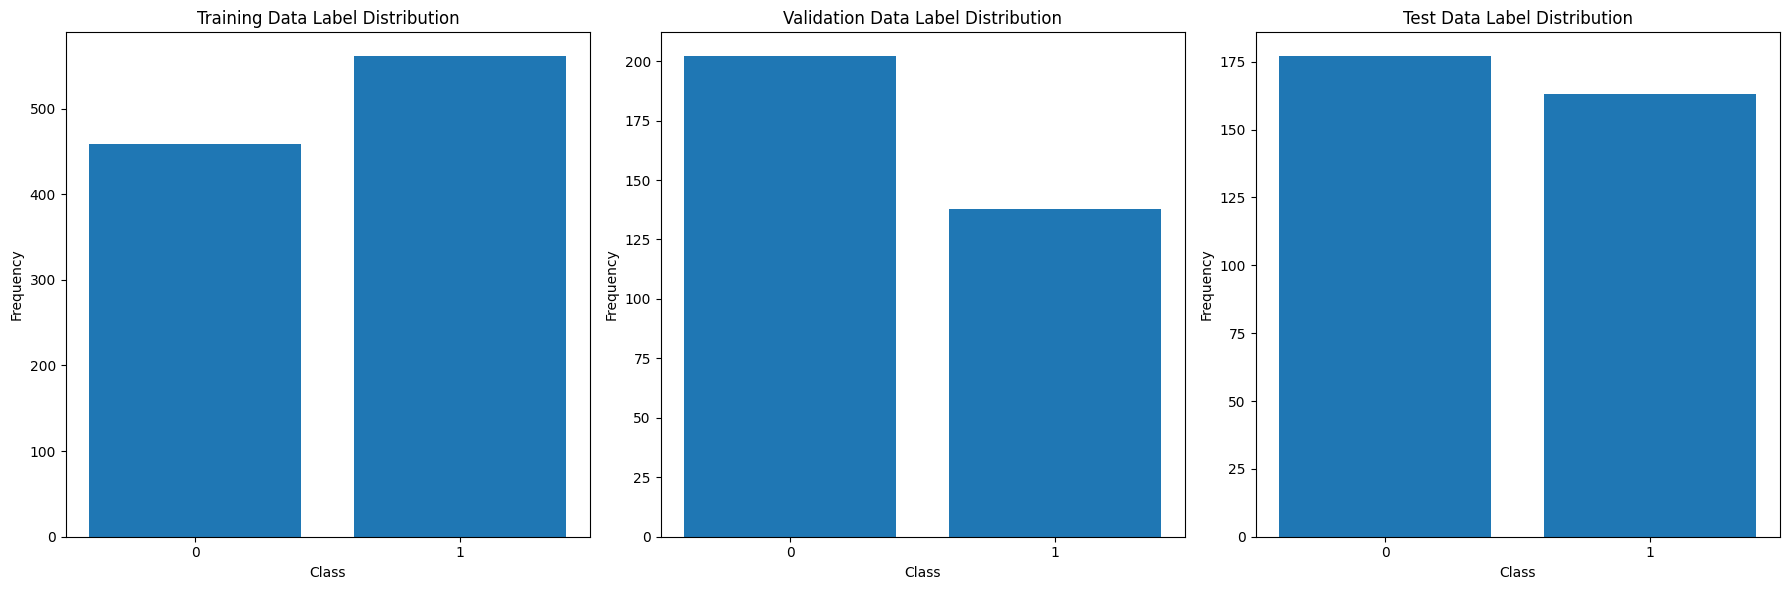

601318.SS.csv 데이터 전처리 및 분포 확인 완료.

600104.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600104.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 490
Training data - class 1: 530
Validation data - class 0: 180
Validation data - class 1: 160
Test data - class 0: 188
Test data - class 1: 152


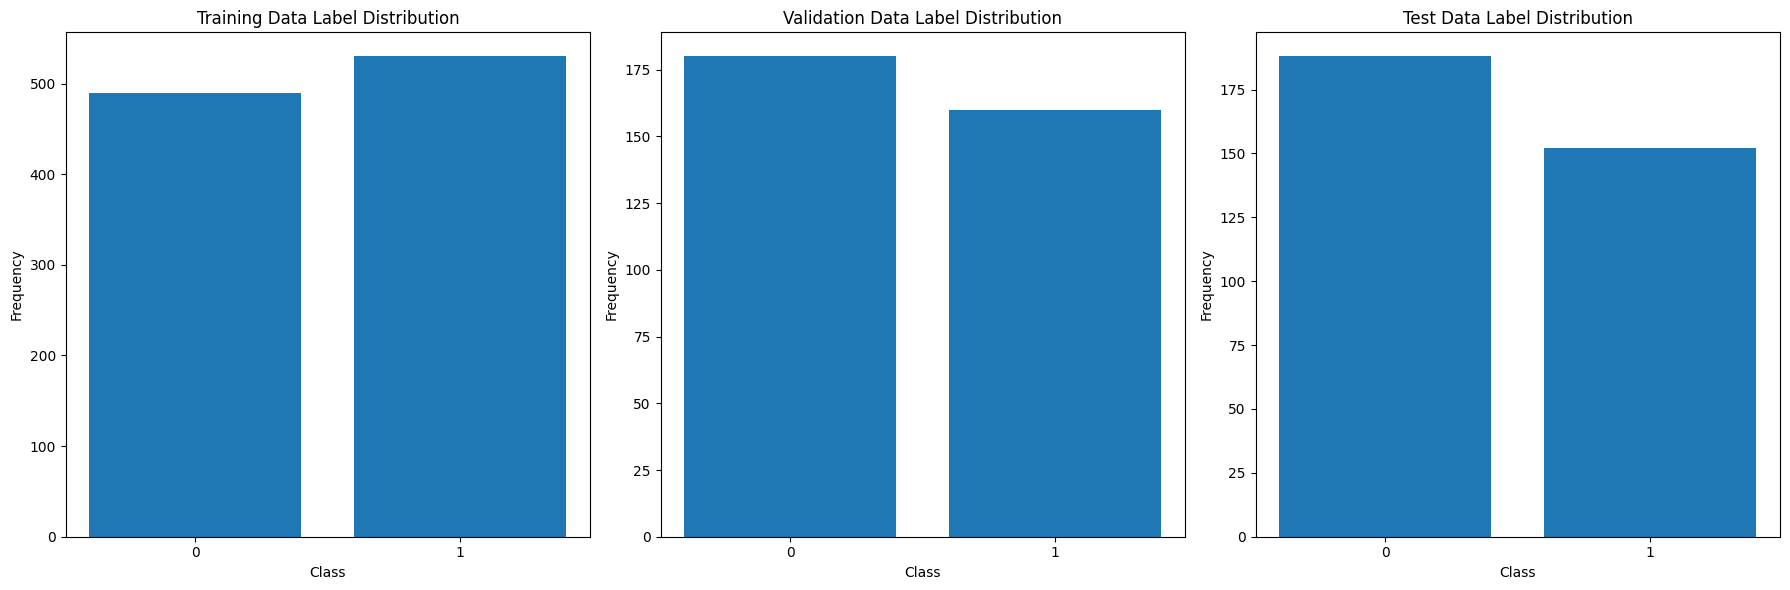

600104.SS.csv 데이터 전처리 및 분포 확인 완료.

601390.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 601390.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 496
Training data - class 1: 524
Validation data - class 0: 188
Validation data - class 1: 152
Test data - class 0: 156
Test data - class 1: 184


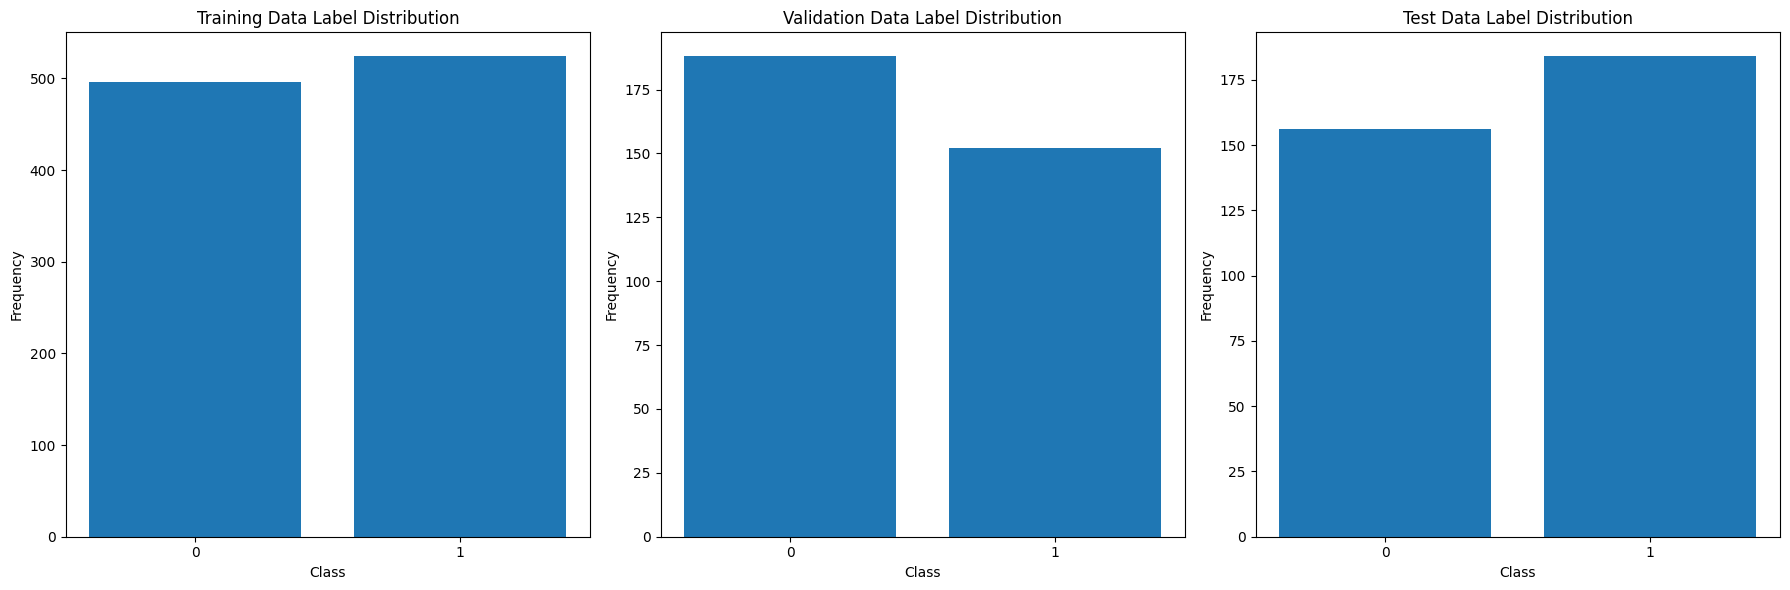

601390.SS.csv 데이터 전처리 및 분포 확인 완료.

600460.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600460.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 461
Training data - class 1: 559
Validation data - class 0: 147
Validation data - class 1: 193
Test data - class 0: 188
Test data - class 1: 152


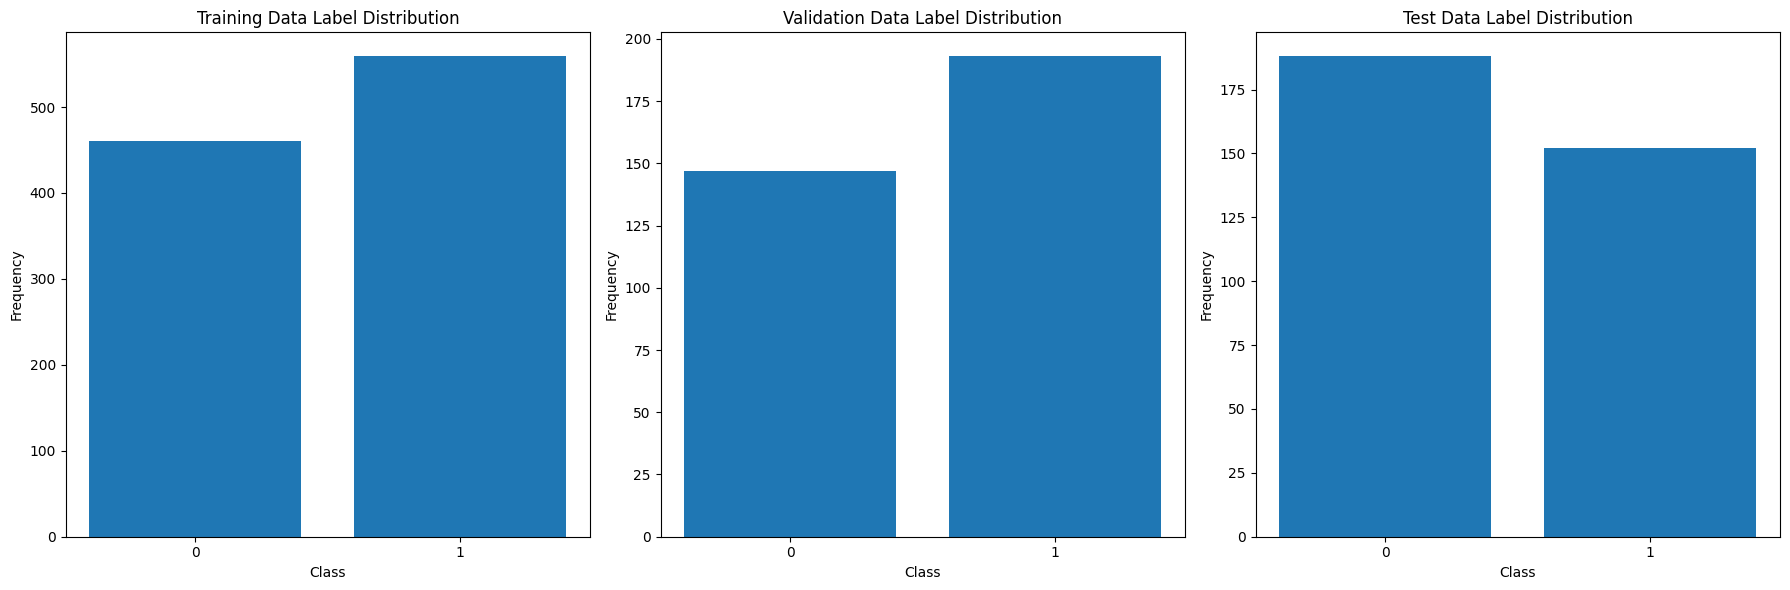

600460.SS.csv 데이터 전처리 및 분포 확인 완료.

600276.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600276.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 419
Training data - class 1: 601
Validation data - class 0: 180
Validation data - class 1: 160
Test data - class 0: 173
Test data - class 1: 167


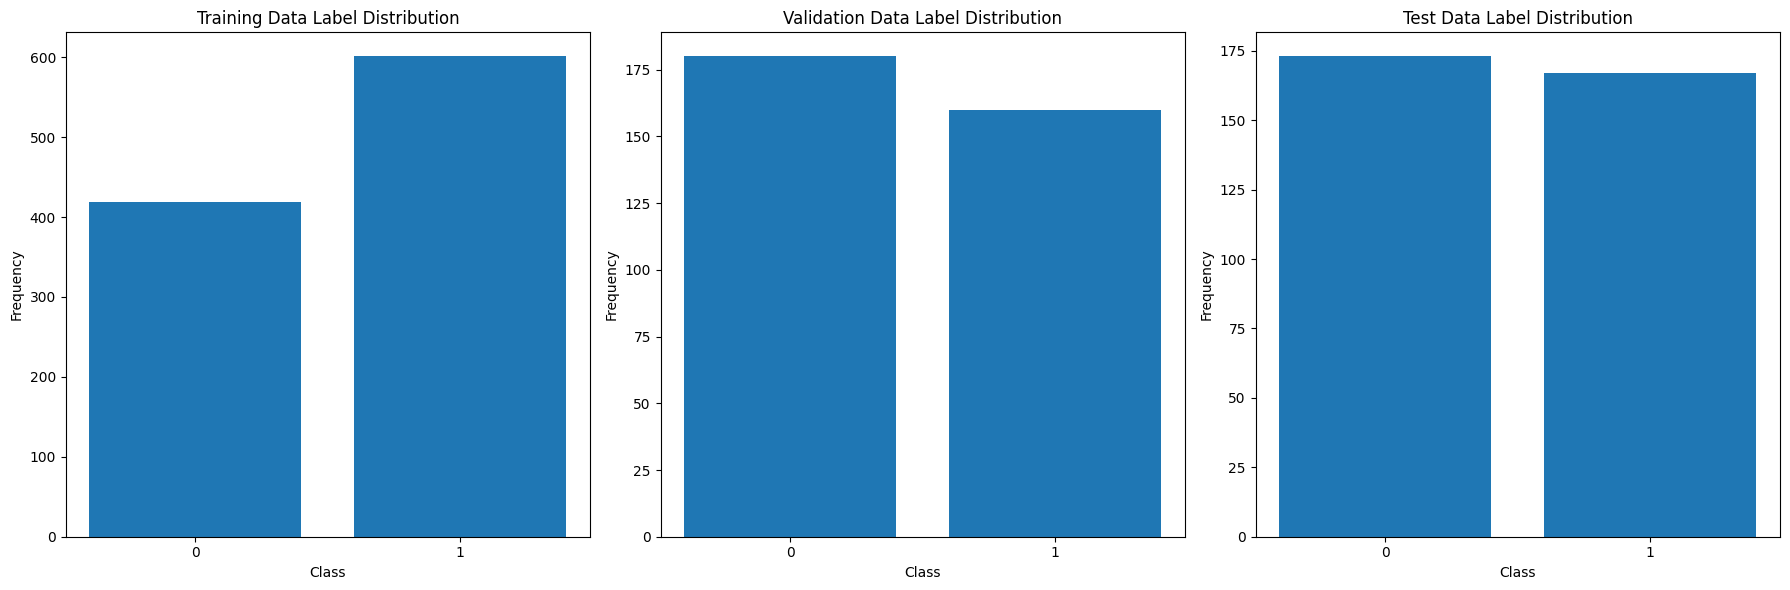

600276.SS.csv 데이터 전처리 및 분포 확인 완료.

000002.SZ.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 000002.SZ.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 486
Training data - class 1: 534
Validation data - class 0: 194
Validation data - class 1: 146
Test data - class 0: 203
Test data - class 1: 137


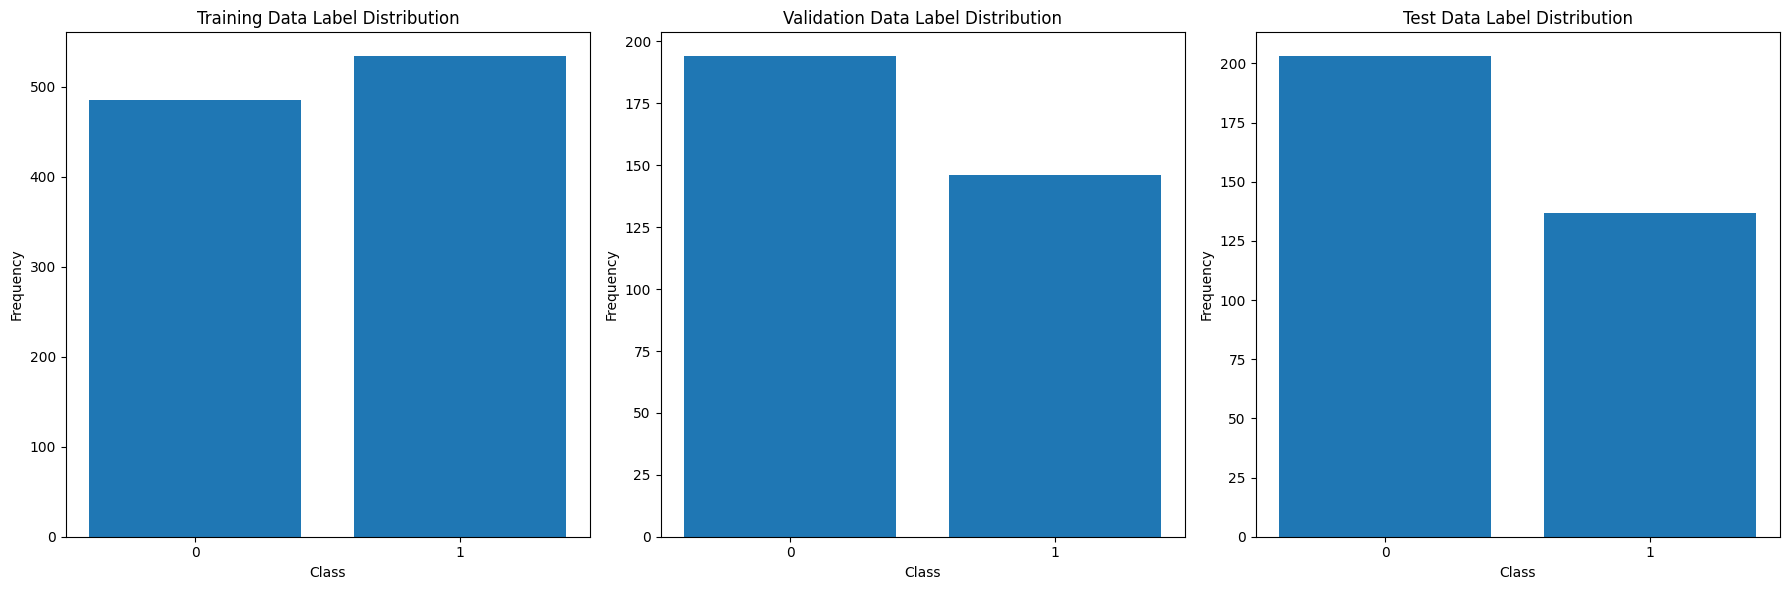

000002.SZ.csv 데이터 전처리 및 분포 확인 완료.

601857.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 601857.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 531
Training data - class 1: 489
Validation data - class 0: 184
Validation data - class 1: 156
Test data - class 0: 145
Test data - class 1: 195


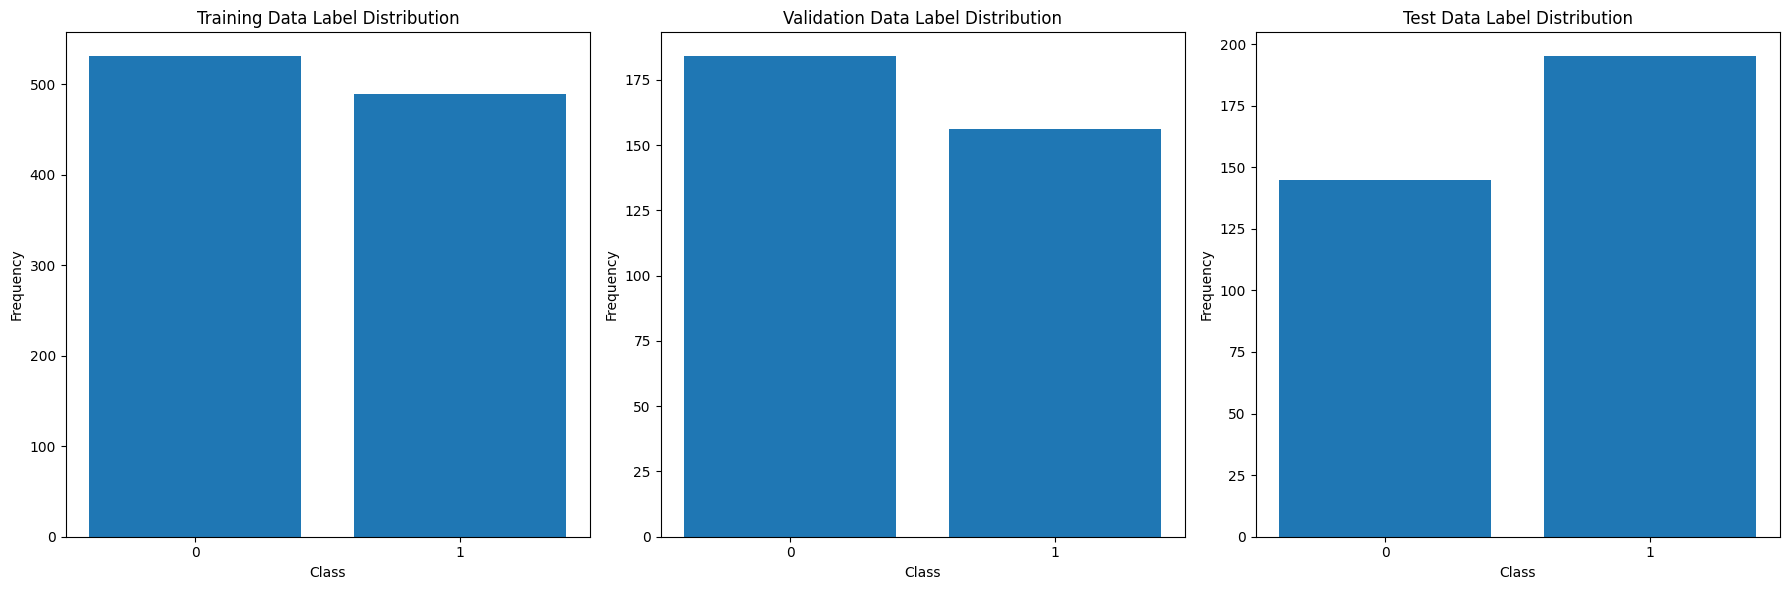

601857.SS.csv 데이터 전처리 및 분포 확인 완료.

600050.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600050.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 465
Training data - class 1: 555
Validation data - class 0: 195
Validation data - class 1: 145
Test data - class 0: 157
Test data - class 1: 183


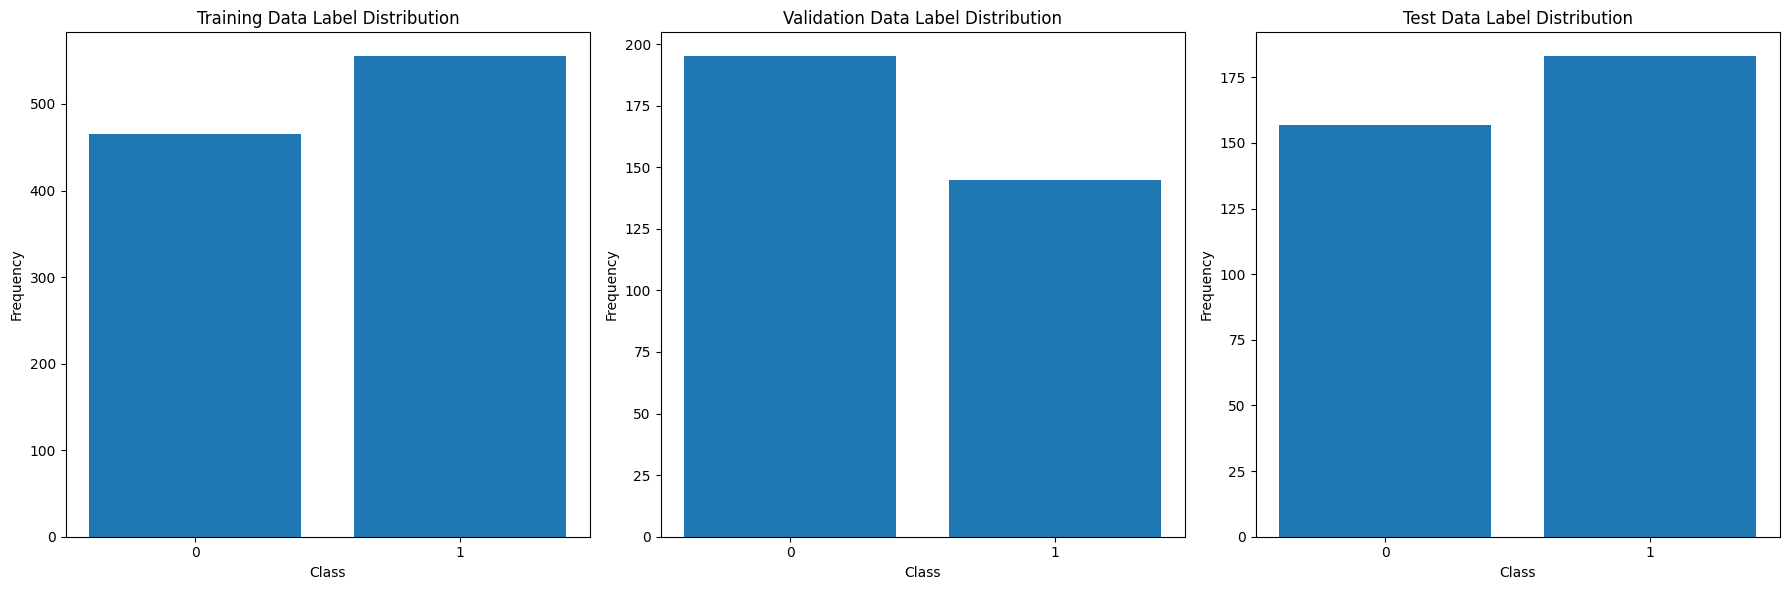

600050.SS.csv 데이터 전처리 및 분포 확인 완료.

600019.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600019.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 457
Training data - class 1: 563
Validation data - class 0: 152
Validation data - class 1: 188
Test data - class 0: 163
Test data - class 1: 177


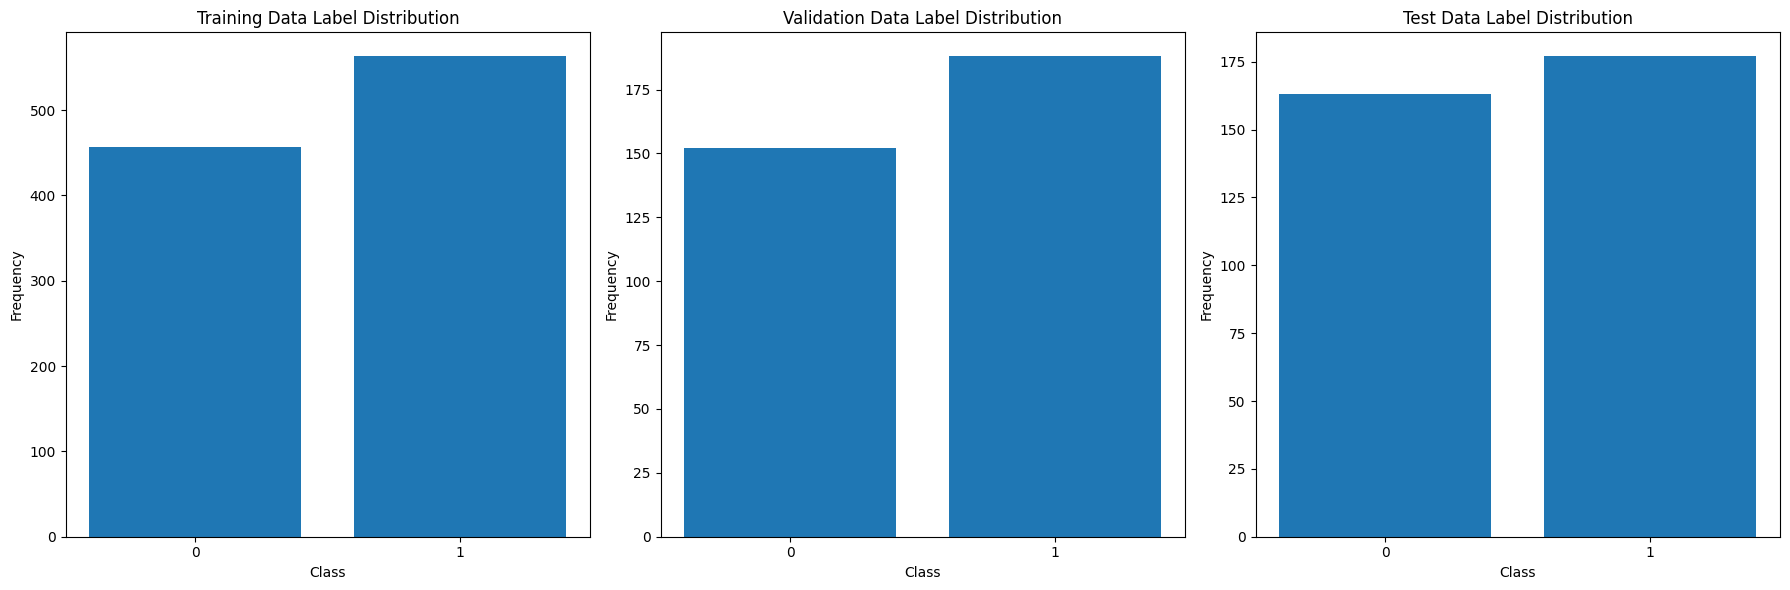

600019.SS.csv 데이터 전처리 및 분포 확인 완료.

600900.SS.csv 데이터 분할 및 시계열 데이터 변환 중...
파일명: 600900.SS.csv
Training data 크기: 1020 rows, 111 columns
Validation data 크기: 340 rows, 111 columns
Test data 크기: 340 rows, 111 columns

Training data - class 0: 464
Training data - class 1: 556
Validation data - class 0: 171
Validation data - class 1: 169
Test data - class 0: 168
Test data - class 1: 172


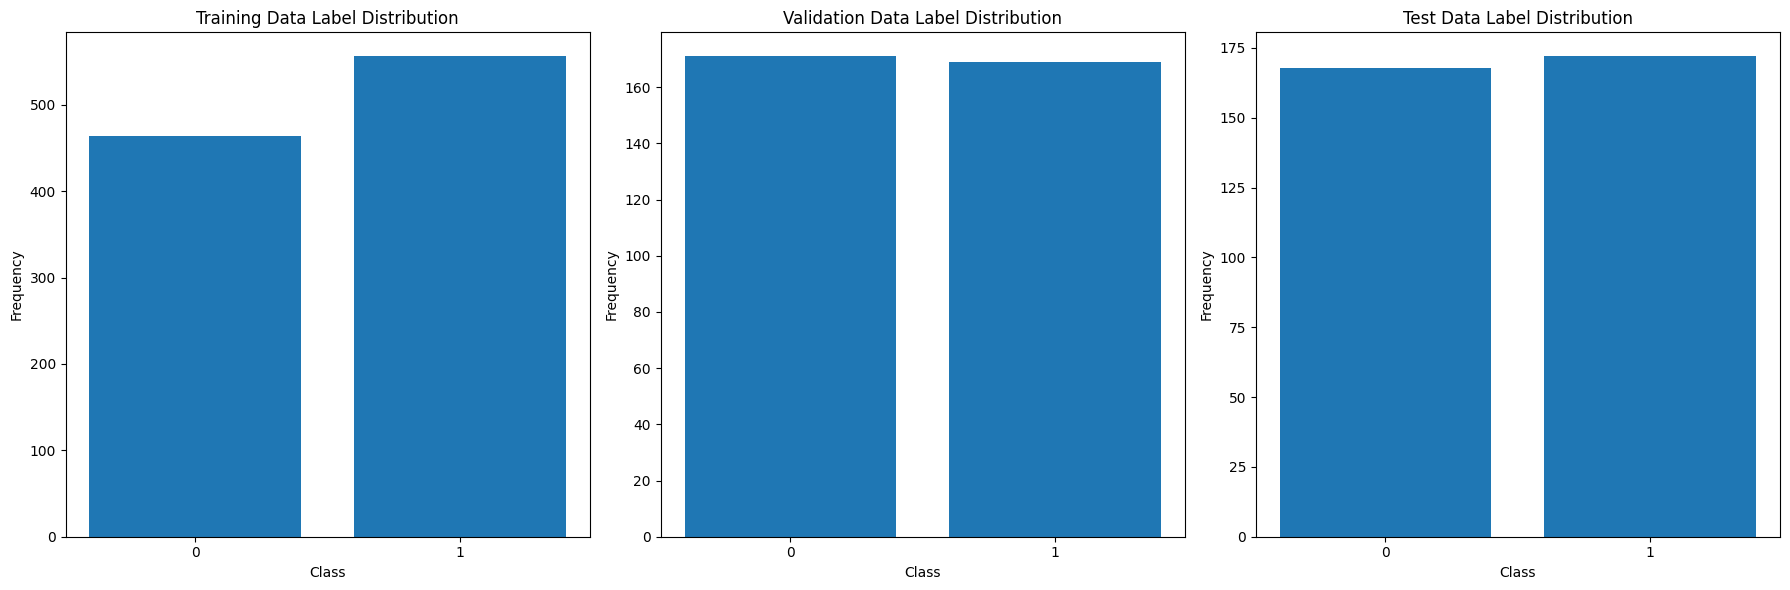

600900.SS.csv 데이터 전처리 및 분포 확인 완료.

모든 파일에 대해 데이터 준비 완료.


In [12]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 전처리된 데이터가 저장된 디렉터리 경로
filtered_dataset_path = '/content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/dataset/sector_1st/filtered_dataset'
results = {}

# 시계열 데이터 변환 함수
def create_sequences(data, num_timesteps):
    sequences = []
    for i in range(len(data) - num_timesteps + 1):
        sequences.append(data[i:i + num_timesteps])
    return np.array(sequences)

# 데이터 준비 및 시계열 데이터 변환
num_timesteps = 5

for filename in os.listdir(filtered_dataset_path):
    if filename.endswith('.csv'):
        print(f"{filename} 데이터 분할 및 시계열 데이터 변환 중...")
        file_path = os.path.join(filtered_dataset_path, filename)

        # 전처리된 데이터 로드
        AllStock = pd.read_csv(file_path, encoding='utf-8-sig')

        # 데이터 분할
        total_rows = len(AllStock)
        split1_end, split2_end = int(0.6 * total_rows), int(0.8 * total_rows)
        data_split1, data_split2, data_split3 = AllStock[:split1_end], AllStock[split1_end:split2_end], AllStock[split2_end:]

        # 입력 피처와 타겟 분리
        train_x, train_y = data_split1.iloc[:, 3:-1], data_split1.iloc[:, -1]
        vali_x, vali_y = data_split2.iloc[:, 3:-1], data_split2.iloc[:, -1]
        test_x, test_y = data_split3.iloc[:, 3:-1], data_split3.iloc[:, -1]

        # 각 데이터셋의 크기 확인
        print(f"파일명: {filename}")
        print(f"Training data 크기: {train_x.shape[0]} rows, {train_x.shape[1]} columns")
        print(f"Validation data 크기: {vali_x.shape[0]} rows, {vali_x.shape[1]} columns")
        print(f"Test data 크기: {test_x.shape[0]} rows, {test_x.shape[1]} columns\n")

        # 스케일링
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train_x)
        vali_x = scaler.transform(vali_x)
        test_x = scaler.transform(test_x)

        # 시계열 데이터 변환
        l_train_x = create_sequences(train_x, num_timesteps)
        l_vali_x = create_sequences(vali_x, num_timesteps)
        l_test_x = create_sequences(test_x, num_timesteps)

        l_train_y = train_y[num_timesteps - 1:].reset_index(drop=True)
        l_vali_y = vali_y[num_timesteps - 1:].reset_index(drop=True)
        l_test_y = test_y[num_timesteps - 1:].reset_index(drop=True)

        # 텐서 변환
        l_train_x = tf.convert_to_tensor(l_train_x, dtype=tf.float32)
        l_vali_x = tf.convert_to_tensor(l_vali_x, dtype=tf.float32)
        l_test_x = tf.convert_to_tensor(l_test_x, dtype=tf.float32)

        l_train_y = tf.convert_to_tensor(l_train_y.values, dtype=tf.float32)
        l_vali_y = tf.convert_to_tensor(l_vali_y.values, dtype=tf.float32)
        l_test_y = tf.convert_to_tensor(l_test_y.values, dtype=tf.float32)

        # 분류 데이터 분포 확인
        datasets, dataset_names = [train_y, vali_y, test_y], ['Training', 'Validation', 'Test']
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))

        for i, (data, name) in enumerate(zip(datasets, dataset_names)):
            unique, counts = np.unique(data, return_counts=True)
            axs[i].bar(unique, counts)
            axs[i].set_title(f'{name} Data Label Distribution')
            axs[i].set_xlabel('Class')
            axs[i].set_ylabel('Frequency')
            axs[i].set_xticks(unique)
            for label, count in zip(unique, counts):
                print(f'{name} data - class {label}: {count}')

        plt.tight_layout()
        plt.show()
        print(f"{filename} 데이터 전처리 및 분포 확인 완료.\n")

        # 결과 저장
        results[filename] = {
            "train_x": l_train_x,
            "train_y": l_train_y,
            "vali_x": l_vali_x,
            "vali_y": l_vali_y,
            "test_x": l_test_x,
            "test_y": l_test_y
        }

print("모든 파일에 대해 데이터 준비 완료.")

In [13]:
target_num = 1

#이것 저것 써보기, learning_rate=0.00001, learning_rate=0.00000001
custom_optimizer = Adam(learning_rate=0.00001)
custom_optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.00001) #이거 ACC 잘나옴
custom_optimizer2 = tf.keras.optimizers.Ftrl(learning_rate=0.01)
custom_optimizer3 = tf.keras.optimizers.Adadelta(learning_rate=1.0)
custom_optimizer4 = tf.keras.optimizers.Adagrad(learning_rate=0.001)
custom_optimizer5 = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

In [14]:
# 데이터셋 크기 확인 함수
def print_dataset_sizes_for_all(results):
    for filename, data in results.items():
        print(f"File: {filename}")

        # 데이터셋 크기 출력
        train_x, train_y = data['train_x'], data['train_y']
        vali_x, vali_y = data['vali_x'], data['vali_y']
        test_x, test_y = data['test_x'], data['test_y']

        print("Training Set:")
        print(f"train_x shape: {train_x.shape}")
        print(f"train_y shape: {train_y.shape}\n")

        print("Validation Set:")
        print(f"vali_x shape: {vali_x.shape}")
        print(f"vali_y shape: {vali_y.shape}\n")

        print("Test Set:")
        print(f"test_x shape: {test_x.shape}")
        print(f"test_y shape: {test_y.shape}\n")

        print("-" * 50)

# 모든 데이터셋 크기 출력
print_dataset_sizes_for_all(results)


File: 601318.SS.csv
Training Set:
train_x shape: (1016, 5, 111)
train_y shape: (1016,)

Validation Set:
vali_x shape: (336, 5, 111)
vali_y shape: (336,)

Test Set:
test_x shape: (336, 5, 111)
test_y shape: (336,)

--------------------------------------------------
File: 600104.SS.csv
Training Set:
train_x shape: (1016, 5, 111)
train_y shape: (1016,)

Validation Set:
vali_x shape: (336, 5, 111)
vali_y shape: (336,)

Test Set:
test_x shape: (336, 5, 111)
test_y shape: (336,)

--------------------------------------------------
File: 601390.SS.csv
Training Set:
train_x shape: (1016, 5, 111)
train_y shape: (1016,)

Validation Set:
vali_x shape: (336, 5, 111)
vali_y shape: (336,)

Test Set:
test_x shape: (336, 5, 111)
test_y shape: (336,)

--------------------------------------------------
File: 600460.SS.csv
Training Set:
train_x shape: (1016, 5, 111)
train_y shape: (1016,)

Validation Set:
vali_x shape: (336, 5, 111)
vali_y shape: (336,)

Test Set:
test_x shape: (336, 5, 111)
test_y shape:

##MLP

Attention Mechanism 없는 기존 MLP 모델

In [15]:
# 모델 구성 함수 정의
def build_model(input_dim, activation='relu'):
    inputs = Input(shape=(input_dim,))
    x = Dense(111, activation=activation)(inputs)  # 첫 번째 Dense 레이어
    x = Dense(222, activation=activation)(x)       # 두 번째 Dense 레이어
    x = Dense(111, activation=activation)(x)       # 세 번째 Dense 레이어
    outputs = Dense(1, activation='sigmoid')(x)  # 출력 레이어
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_model(input_dim=input_dim)
    model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 222)                 │          24,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 111)                 │          24,753 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 62,161 (242.82 KB)

 Trainable params: 62,161 (242.82 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# MLP_111 모델 (111, 111, 111 차원 Dense 레이어)
def build_mlp_111_model(input_dim, activation='relu'):
    inputs = Input(shape=(input_dim,))
    x = Dense(111, activation='relu')(inputs)
    x = Dense(111, activation='relu')(x)
    x = Dense(111, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_mlp_111_model(input_dim=input_dim)
    model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,408 (146.12 KB)

 Trainable params: 37,408 (146.12 KB)

 Non-trainable params: 0 (0.00 B)

##MLPA

기존 MLP 모델에 단순히 self-attention Mechanism을 추가한 형태

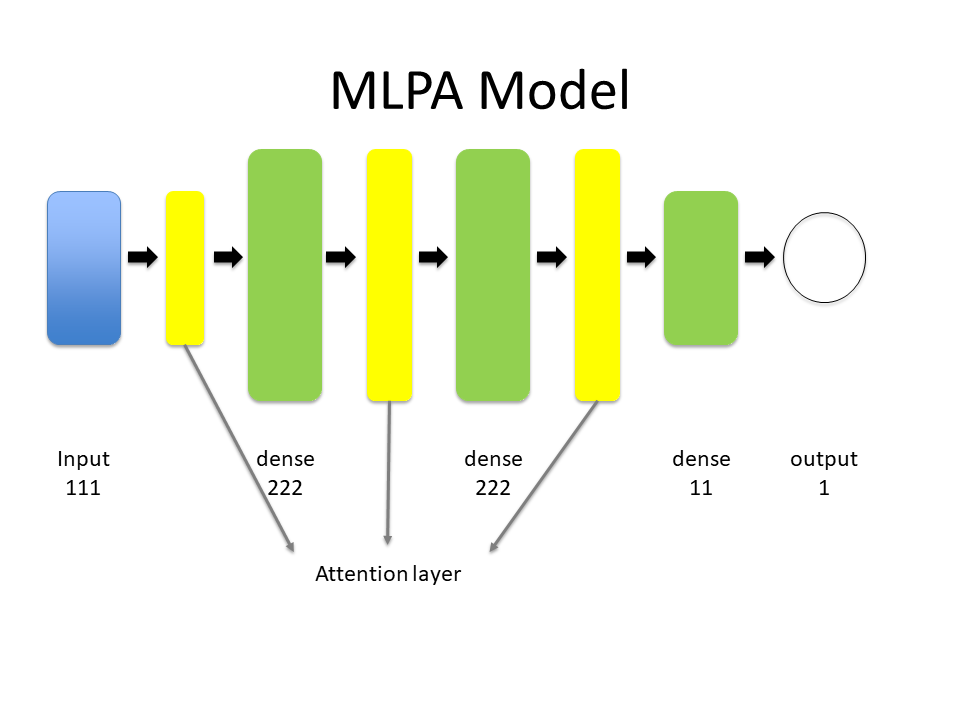

In [17]:
# MLPA 모델 구성 함수 정의
def build_MLPA_model(input_dim, activation='relu'):
    """
    Attention 레이어를 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPA 모델
    """
    inputs = Input(shape=(input_dim,))
    x = AttentionLayerCustom(num_features=111)(inputs)  # 첫 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    x = AttentionLayerCustom(num_features=111)(x)  # 두 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    x = AttentionLayerCustom(num_features=111)(x)  # 세 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPA_model(input_dim=input_dim)
    model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom               │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_1             │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_2             │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 148,297 (579.29 KB)

 Trainable params: 148,297 (579.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# MLPA 모델 구성 함수 정의 (Dense 크기가 증가하는 구조)
def build_MLPA_1_model(input_dim, activation='relu'):
    """
    Dense 크기가 점차 증가하며 Attention 레이어를 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPA 모델
    """
    inputs = Input(shape=(input_dim,))
    x = AttentionLayerCustom(num_features=111)(inputs)
    x = Dense(111, activation=activation)(x)
    x = AttentionLayerCustom(num_features=222)(x)
    x = Dense(222, activation=activation)(x)
    x = AttentionLayerCustom(num_features=111)(x)
    x = Dense(111, activation=activation)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    return model
if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPA_1_model(input_dim=input_dim)
    model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_3             │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 111)                 │          12,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_4             │ (None, 111)                 │          61,605 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 222)                 │          24,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_5             │ (None, 222)                 │          98,568 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 111)                 │          24,753 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 259,297 (1012.88 KB)

 Trainable params: 259,297 (1012.88 KB)

 Non-trainable params: 0 (0.00 B)

##MLPAFC

MLPA 모델과 달리 MLP 모델에서 각 레이어 단계에서 attention 값들을 추출한 후에 마지막 output 전에 concat해서 출력(이전 레이어들에는 attention 매커니즘을 통한 학습이 이루어지지 않음, 단순히 attention 값만 추출한 후 output 전에 concat)

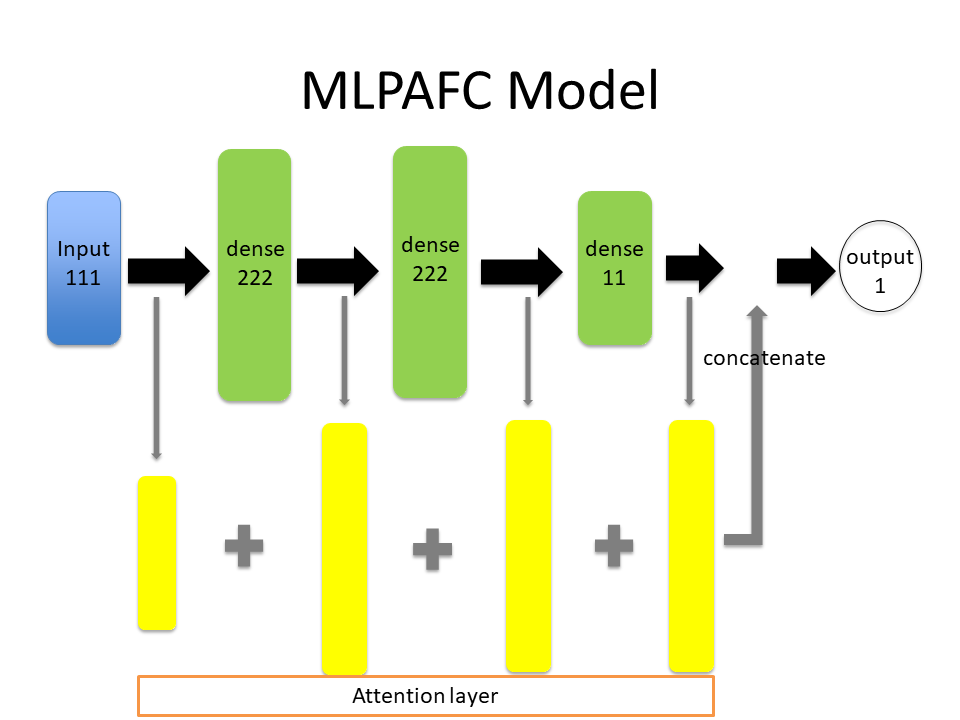

In [19]:
# # MLPAFC 모델 구성 함수 정의(수정전)
# def build_MLPAFC_model(input_dim, activation='relu'):
#     inputs = Input(shape=(input_dim,))
#     a0 = AttentionLayer()(inputs)
#     x = Dense(111, activation=activation)(a0)
#     a1 = AttentionLayer()(x)
#     x = Dense(111, activation=activation)(a1)
#     a2 = AttentionLayer()(x)
#     x = Dense(111, activation=activation)(a2)
#     a3 = AttentionLayer()(x)

#     # Concatenate the attention outputs
#     concatenated = Concatenate()([a0, a1, a2, a3])

#     # Reduce the dimension to 111 using a Dense layer
#     reduced = Dense(111, activation=activation)(concatenated)

#     # Final output layer
#     outputs = Dense(1, activation='sigmoid')(reduced)
#     model = Model(inputs=inputs, outputs=outputs)

#     return model

In [20]:
# MLPAFC 모델 구성 함수 정의
def build_MLPAFC_model(input_dim, activation='relu'):
    """
    Attention 레이어와 Concatenate를 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFC 모델
    """
    inputs = Input(shape=(input_dim,))
    x = Dense(111, activation=activation)(inputs)
    a0 = AttentionLayerCustom(num_features=111)(inputs)  # 첫 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    a1 = AttentionLayerCustom(num_features=111)(x)  # 두 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=111)(x)  # 세 번째 Attention Layer
    concatenated = Concatenate()([a0, a1, a2])  # 모든 Attention 출력 병합
    reduced = Dense(111, activation=activation)(concatenated)
    combined = Add()([x, reduced])
    outputs = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFC_model(input_dim=input_dim)
    model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 111)            │         12,432 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 111)            │         12,432 │ dense_16[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 111)            │         12,432 │ dense_17[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_6  │ (None, 111)            │         36,963 │ input_layer_4[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_7  │ (None, 111)            │         36,963 │ dense_17[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_8  │ (None, 111)            │         36,963 │ dense_18[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 333)            │              0 │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_19 (Dense)          │ (None, 111)            │         37,074 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 111)            │              0 │ dense_18[0][0],        │
│                           │                        │                │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 1)              │            112 │ add[0][0]              │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 185,371 (724.11 KB)

 Trainable params: 185,371 (724.11 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# MLPAFC 모델 구성 함수 정의 (Dense 크기가 증가하는 구조)
def build_MLPAFC_1_model(input_dim, activation='relu'):
    """
    Dense 크기가 증가하며 Attention 레이어와 Concatenate를 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFC 모델
    """
    inputs = Input(shape=(input_dim,))
    x = Dense(111, activation=activation)(inputs)
    a0 = AttentionLayerCustom(num_features=111)(inputs)  # 첫 번째 Attention Layer
    x = Dense(222, activation=activation)(x)
    a1 = AttentionLayerCustom(num_features=222)(x)  # 두 번째 Attention Layer
    x = Dense(111, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=111)(x)  # 세 번째 Attention Layer
    concatenated = Concatenate()([a0, a1, a2])  # 모든 Attention 출력 병합
    reduced = Dense(111, activation=activation)(concatenated)
    combined = Add()([x, reduced])
    outputs = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFC_1_model(input_dim=input_dim)
    model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_21 (Dense)          │ (None, 111)            │         12,432 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_22 (Dense)          │ (None, 222)            │         24,864 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_23 (Dense)          │ (None, 111)            │         24,753 │ dense_22[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_9  │ (None, 111)            │         36,963 │ input_layer_5[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_10 │ (None, 222)            │        147,852 │ dense_22[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_11 │ (None, 111)            │         36,963 │ dense_23[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 444)            │              0 │ attention_layer_custo… │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_24 (Dense)          │ (None, 111)            │         49,395 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 111)            │              0 │ dense_23[0][0],        │
│                           │                        │                │ dense_24[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_25 (Dense)          │ (None, 1)              │            112 │ add_1[0][0]            │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 333,334 (1.27 MB)

 Trainable params: 333,334 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

##MLPAFCR

In [22]:
# # MLPAFCR 모델 구성 함수 정의
# def build_MLPAFCR_model(input_dim, activation='relu'):
#     inputs = Input(shape=(input_dim,))

#     # 첫 번째 Attention Layer 및 Dense Layer
#     a0 = AttentionLayer()(inputs)
#     x = Dense(111, activation=activation)(inputs)
#     a1 = AttentionLayer()(x)

#     # 첫 번째 Residual Connection
#     x = Add()([x, a1])

#     # 두 번째 Dense Layer 및 Attention Layer
#     x = Dense(111, activation=activation)(x)
#     a2 = AttentionLayer()(x)

#     # 두 번째 Residual Connection
#     x = Add()([x, a2])

#     # 세 번째 Dense Layer 및 Attention Layer
#     x = Dense(111, activation=activation)(x)
#     a3 = AttentionLayer()(x)

#     # 세 번째 Residual Connection
#     x = Add()([x, a3])

#     # Concatenate 모든 Attention Layer
#     concatenated = Concatenate()([a0, a1, a2, a3])
#     outputs = Dense(1, activation='sigmoid')(concatenated)
#     model = Model(inputs=inputs, outputs=outputs)
#     return model

In [23]:
# MLPAFCR 모델 구성 함수 정의 (Residual Connection 포함)
def build_MLPAFCR_model(input_dim, activation='relu'):
    """
    Attention 레이어와 Residual Connection을 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFCR 모델
    """
    inputs = Input(shape=(input_dim,))
    a0 = AttentionLayerCustom(num_features=111)(inputs)
    x = Dense(111, activation=activation)(inputs)
    a1 = AttentionLayerCustom(num_features=111)(x)
    x = Add()([x, a1])  # Residual Connection
    x = Dense(111, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=111)(x)
    x = Add()([x, a2])  # Residual Connection
    x = Dense(111, activation=activation)(x)
    a3 = AttentionLayerCustom(num_features=111)(x)
    x = Add()([x, a3])  # Residual Connection
    concatenated = Concatenate()([a0, a1, a2, a3])  # 모든 Attention Layer 병합
    reduced = Dense(111, activation=activation)(concatenated)
    combined = Add()([x, reduced])
    outputs = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFCR_model(input_dim=input_dim)
    model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_26 (Dense)          │ (None, 111)            │         12,432 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_13 │ (None, 111)            │         36,963 │ dense_26[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 111)            │              0 │ dense_26[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_27 (Dense)          │ (None, 111)            │         12,432 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_14 │ (None, 111)            │         36,963 │ dense_27[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 111)            │              0 │ dense_27[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_28 (Dense)          │ (None, 111)            │         12,432 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_15 │ (None, 111)            │         36,963 │ dense_28[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_12 │ (None, 111)            │         36,963 │ input_layer_6[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 444)            │              0 │ attention_layer_custo… │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_4 (Add)               │ (None, 111)            │              0 │ dense_28[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_29 (Dense)          │ (None, 111)            │         49,395 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_5 (Add)               │ (None, 111)            │              0 │ add_4[0][0],           │
│                      

 Total params: 234,655 (916.62 KB)

 Trainable params: 234,655 (916.62 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# MLPAFCR_1 모델 구성 함수 정의 (Residual Connection 포함)
def build_MLPAFCR_1_model(input_dim, activation='relu'):
    """
    Attention 레이어와 Residual Connection을 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFCR 모델
    """
    inputs = Input(shape=(input_dim,))
    a0 = AttentionLayerCustom(num_features=111)(inputs)
    x = Dense(111, activation=activation)(inputs)
    a1 = AttentionLayerCustom(num_features=111)(x)
    x = Add()([x, a1])  # Residual Connection
    x = Dense(222, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=222)(x)
    x = Add()([x, a2])  # Residual Connection
    x = Dense(111, activation=activation)(x)
    a3 = AttentionLayerCustom(num_features=111)(x)
    x = Add()([x, a3])  # Residual Connection
    concatenated = Concatenate()([a0, a1, a2, a3])  # 모든 Attention Layer 병합
    reduced = Dense(111, activation=activation)(concatenated)
    combined = Add()([x, reduced])
    outputs = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFCR_1_model(input_dim=input_dim)
    model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_31 (Dense)          │ (None, 111)            │         12,432 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_17 │ (None, 111)            │         36,963 │ dense_31[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_6 (Add)               │ (None, 111)            │              0 │ dense_31[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_32 (Dense)          │ (None, 222)            │         24,864 │ add_6[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_18 │ (None, 222)            │        147,852 │ dense_32[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_7 (Add)               │ (None, 222)            │              0 │ dense_32[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_33 (Dense)          │ (None, 111)            │         24,753 │ add_7[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_19 │ (None, 111)            │         36,963 │ dense_33[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_16 │ (None, 111)            │         36,963 │ input_layer_7[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 555)            │              0 │ attention_layer_custo… │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_8 (Add)               │ (None, 111)            │              0 │ dense_33[0][0],        │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_34 (Dense)          │ (None, 111)            │         61,716 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_9 (Add)               │ (None, 111)            │              0 │ add_8[0][0],           │
│                      

 Total params: 382,618 (1.46 MB)

 Trainable params: 382,618 (1.46 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# MLPAFCR_2 모델 구성 함수 정의 (수정된 구조)
def build_MLPAFCR_2_model(input_dim, activation='relu'):
    """
    Attention 레이어와 Residual Connection (Concatenate 방식)을 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFCR_2 모델
    """
    inputs = Input(shape=(input_dim,))

    # 첫 번째 Attention Layer와 Dense Layer
    a0 = AttentionLayerCustom(num_features=111)(inputs)  # 첫 번째 Attention Layer
    x = Dense(111, activation=activation)(inputs)
    a1 = AttentionLayerCustom(num_features=111)(x)  # 두 번째 Attention Layer
    x = Concatenate()([x, a1])  # Residual Connection (Concatenate 방식)

    # 두 번째 Dense Layer와 Attention Layer
    x = Dense(222, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=222)(x)  # 세 번째 Attention Layer
    x = Concatenate()([x, a2])  # Residual Connection (Concatenate 방식)

    # 세 번째 Dense Layer와 Attention Layer
    x = Dense(111, activation=activation)(x)
    a3 = AttentionLayerCustom(num_features=111)(x)  # 네 번째 Attention Layer
    x = Concatenate()([x, a3])  # Residual Connection (Concatenate 방식)

    # 모든 Attention Layer를 Concatenate
    attention_concatenated = Concatenate()([a0, a1, a2, a3])

    # Attention Layer 출력 크기를 111차원으로 축소
    attention_reduced = Dense(111, activation=activation)(attention_concatenated)

    # 세 번째 Dense Layer 결과와 Attention Layer Reduced를 Concatenate
    combined_concatenated = Concatenate()([x, attention_reduced])

    # 최종 Concatenated 결과를 111차원으로 축소
    final_reduced = Dense(111, activation=activation)(combined_concatenated)

    # 최종 출력층
    outputs = Dense(1, activation='sigmoid')(final_reduced)

    # 모델 생성
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFCR_2_model(input_dim=input_dim)
    model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_36 (Dense)          │ (None, 111)            │         12,432 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_21 │ (None, 111)            │         36,963 │ dense_36[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 222)            │              0 │ dense_36[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_37 (Dense)          │ (None, 222)            │         49,506 │ concatenate_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_22 │ (None, 222)            │        147,852 │ dense_37[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_5             │ (None, 444)            │              0 │ dense_37[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_38 (Dense)          │ (None, 111)            │         49,395 │ concatenate_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_23 │ (None, 111)            │         36,963 │ dense_38[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_20 │ (None, 111)            │         36,963 │ input_layer_8[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_7             │ (None, 555)            │              0 │ attention_layer_custo… │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_6             │ (None, 222)            │              0 │ dense_38[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_39 (Dense)          │ (None, 111)            │         61,716 │ concatenate_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_8             │ (None, 333)            │              0 │ concatenate_6[0][0],   │
│ (Concatenate)        

 Total params: 468,976 (1.79 MB)

 Trainable params: 468,976 (1.79 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# MLPAFCR_3 모델 구성 함수 정의 (수정된 구조)
def build_MLPAFCR_3_model(input_dim, activation='relu'):
    """
    Attention 레이어와 Residual Connection (Concatenate 방식)을 포함한 MLP 모델

    Args:
        input_dim (int): 입력 피처의 크기
        activation (str): 활성화 함수 (기본값: 'relu')

    Returns:
        Model: MLPAFCR_3 모델
    """
    inputs = Input(shape=(input_dim,))

    # 첫 번째 Attention Layer와 Dense Layer
    a0 = AttentionLayerCustom(num_features=111)(inputs)  # 첫 번째 Attention Layer
    x = Dense(111, activation=activation)(inputs)
    a1 = AttentionLayerCustom(num_features=111)(x)  # 두 번째 Attention Layer
    x = Concatenate()([x, a1])  # Residual Connection (Concatenate 방식)

    # 두 번째 Dense Layer와 Attention Layer
    x = Dense(111, activation=activation)(x)
    a2 = AttentionLayerCustom(num_features=111)(x)  # 세 번째 Attention Layer
    x = Concatenate()([x, a2])  # Residual Connection (Concatenate 방식)

    # 세 번째 Dense Layer와 Attention Layer
    x = Dense(111, activation=activation)(x)
    a3 = AttentionLayerCustom(num_features=111)(x)  # 네 번째 Attention Layer
    x = Concatenate()([x, a3])  # Residual Connection (Concatenate 방식)

    # 모든 Attention Layer를 Concatenate
    attention_concatenated = Concatenate()([a0, a1, a2, a3])

    # Attention Layer 출력 크기를 111차원으로 축소
    attention_reduced = Dense(111, activation=activation)(attention_concatenated)

    # 세 번째 Dense Layer 결과와 Attention Layer Reduced를 Concatenate
    combined_concatenated = Concatenate()([x, attention_reduced])

    # 최종 Concatenated 결과를 111차원으로 축소
    final_reduced = Dense(111, activation=activation)(combined_concatenated)

    # 최종 출력층
    outputs = Dense(1, activation='sigmoid')(final_reduced)

    # 모델 생성
    model = Model(inputs=inputs, outputs=outputs)
    return model

if __name__ == "__main__":
    input_dim = 111  # 입력 피처 크기
    model = build_MLPAFCR_3_model(input_dim=input_dim)
    model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9             │ (None, 111)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_42 (Dense)          │ (None, 111)            │         12,432 │ input_layer_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_25 │ (None, 111)            │         36,963 │ dense_42[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_9             │ (None, 222)            │              0 │ dense_42[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_43 (Dense)          │ (None, 111)            │         24,753 │ concatenate_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_26 │ (None, 111)            │         36,963 │ dense_43[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_10            │ (None, 222)            │              0 │ dense_43[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_44 (Dense)          │ (None, 111)            │         24,753 │ concatenate_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_27 │ (None, 111)            │         36,963 │ dense_44[0][0]         │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_layer_custom_24 │ (None, 111)            │         36,963 │ input_layer_9[0][0]    │
│ (AttentionLayerCustom)    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_12            │ (None, 444)            │              0 │ attention_layer_custo… │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
│                           │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_11            │ (None, 222)            │              0 │ dense_44[0][0],        │
│ (Concatenate)             │                        │                │ attention_layer_custo… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_45 (Dense)          │ (None, 111)            │         49,395 │ concatenate_12[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_13            │ (None, 333)            │              0 │ concatenate_11[0][0],  │
│ (Concatenate)        

 Total params: 296,371 (1.13 MB)

 Trainable params: 296,371 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

###MLP_Autoencoder

In [27]:
def build_autoencoder(input_dim, latent_dim):
    # 인코더
    inputs = Input(shape=(input_dim,))
    x = Dense(64, activation='relu')(inputs)  # 111 → 64
    latent = Dense(latent_dim, activation='relu')(x)  # 64 → 32

    # 디코더
    x = Dense(64, activation='relu')(latent)  # 32 → 64
    x = Dense(input_dim, activation='relu')(x)  # 64 → 111
    outputs = Dense(1, activation='sigmoid')(x)  # 이진 분류용 출력층

    # Autoencoder 모델
    autoencoder = Model(inputs=inputs, outputs=outputs)

    return autoencoder

# 모델 생성 및 컴파일
input_dim = 111  # 입력 차원
latent_dim = 32  # 줄이고 싶은 차원
autoencoder_model = build_autoencoder(input_dim, latent_dim)

# 이진 분류용으로 손실 함수 설정
autoencoder_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 요약 출력
autoencoder_model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 64)                  │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 111)                 │           7,215 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,687 (73.00 KB)

 Trainable params: 18,687 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

###MLPA_Autoencoder

In [28]:
# Autoencoder 모델에 사용자 정의 Attention 레이어를 추가하는 함수
def build_autoencoder_with_attention(input_dim, latent_dim):
    # 입력층 및 Attention Layer 추가
    inputs = Input(shape=(input_dim,))
    x = AttentionLayerCustom(num_features=input_dim)(inputs)  # Self-Attention 추가 (인풋 바로 다음)
    x = Dense(64, activation='relu')(x)  # 111 → 64
    x = AttentionLayerCustom(num_features=64)(x)  # Self-Attention 추가
    x = Dense(32, activation='relu')(x)  # 64 → 32
    x = AttentionLayerCustom(num_features=32)(x)  # Self-Attention 추가
    latent = Dense(latent_dim, activation='relu')(x)  # 32 → latent_dim

    # 디코더
    x = Dense(32, activation='relu')(latent)  # latent_dim → 32
    x = AttentionLayerCustom(num_features=32)(x)  # Self-Attention 추가
    x = Dense(64, activation='relu')(x)  # 32 → 64
    x = AttentionLayerCustom(num_features=64)(x)  # Self-Attention 추가
    x = Dense(input_dim, activation='relu')(x)  # 64 → 111
    x = AttentionLayerCustom(num_features=input_dim)(x)  # Self-Attention 추가 (아웃풋 바로 전)

    # 이진 분류를 위한 출력층
    outputs = Dense(1, activation='sigmoid')(x)

    # Autoencoder 모델 생성
    autoencoder = Model(inputs=inputs, outputs=outputs)
    return autoencoder

# 모델 생성 및 컴파일
input_dim = 111  # 입력 차원
latent_dim = 32  # 잠재 차원
autoencoder_model = build_autoencoder_with_attention(input_dim, latent_dim)

# 컴파일
autoencoder_model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

# 모델 요약 출력
autoencoder_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 111)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_28            │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 64)                  │           7,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_29            │ (None, 64)                  │          12,288 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_30            │ (None, 32)                  │           3,072 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_31            │ (None, 32)                  │           3,072 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_32            │ (None, 64)                  │          12,288 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 111)                 │           7,215 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_custom_33            │ (None, 111)                 │          36,963 │
│ (AttentionLayerCustom)               │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 1)                   │             112 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 125,445 (490.02 KB)

 Trainable params: 125,445 (490.02 KB)

 Non-trainable params: 0 (0.00 B)

##실험

In [ ]:
# 전처리된 데이터셋이 저장된 디렉터리 경로 설정
filtered_dataset_path = os.path.join(directory_path, 'filtered_dataset')

# 데이터셋에서 Feature 이름 추출
def extract_feature_names(df):
    return df.columns[3:-1].tolist()

# 모델 함수 리스트
model_functions = {
    'Base Model': build_model,
    'MLP_111 Model': build_mlp_111_model,
    'MLPA Model': build_MLPA_model,
    'MLPA_1 Model': build_MLPA_1_model,
    'MLPAFC Model': build_MLPAFC_model,
    'MLPAFC_1 Model': build_MLPAFC_1_model,
    'MLPAFCR Model': build_MLPAFCR_model,
    'MLPAFCR_1 Model': build_MLPAFCR_1_model,
    'MLPAFCR_2 Model': build_MLPAFCR_2_model,
    'MLPAFCR_3 Model': build_MLPAFCR_3_model,
    'Autoencoder Model': build_autoencoder,
    'Autoencoder_A Model': build_autoencoder_with_attention,
}

# 학습 함수 정의 (어텐션 가중치 히트맵 시각화 포함)
def train_models_on_datasets_with_attention(model_functions, train_data, vali_data, test_data, feature_names, symbol, epochs=10, batch_size=128):
    now = datetime.now().strftime('%Y%m%d_%H%M%S')
    results_dir = f'./results_{now}/{symbol}'
    os.makedirs(results_dir, exist_ok=True)

    train_x, train_y = train_data
    vali_x, vali_y = vali_data
    test_x, test_y = test_data

    for model_name, model_fn in model_functions.items():
        print(f"\nTraining {model_name} on {symbol}...")
        log_file_path = os.path.join(results_dir, f"{symbol}_{model_name}_Log.txt")

        try:
            # 모델 생성
            if model_name in ["Autoencoder Model", "Autoencoder_A Model"]:
                model = model_fn(input_dim=train_x.shape[1], latent_dim=32)
            else:
                model = model_fn(input_dim=train_x.shape[1])

            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

            # 어텐션 레이어 추출
            attention_layers = [layer for layer in model.layers if isinstance(layer, AttentionLayerCustom)]
            attention_model = None
            if attention_layers:
                attention_outputs = [layer.output for layer in attention_layers]
                attention_model = Model(inputs=model.input, outputs=attention_outputs)

            # 학습 및 기록
            history = model.fit(
                train_x, train_y,
                validation_data=(vali_x, vali_y),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0
            )

            # 로그 파일 기록
            with open(log_file_path, 'w') as log_file:
                log_file.write(f"{model_name} Training Log for {symbol}\n")
                log_file.write("=" * 50 + "\n")

                for epoch in range(epochs):
                    train_acc = history.history['accuracy'][epoch]
                    val_acc = history.history['val_accuracy'][epoch]
                    train_loss = history.history['loss'][epoch]
                    val_loss = history.history['val_loss'][epoch]

                    log_file.write(
                        f"Epoch {epoch + 1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                        f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}\n"
                    )

                    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
                        print(
                            f"{model_name} - Epoch {epoch + 1}/{epochs}: "
                            f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
                            f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}"
                        )

                # 테스트 평가
                test_loss, test_accuracy = model.evaluate(test_x, test_y, verbose=0)
                y_pred = (model.predict(test_x) > 0.5).astype(int)
                precision = precision_score(test_y, y_pred)
                recall = recall_score(test_y, y_pred)
                f1 = f1_score(test_y, y_pred)

                log_file.write(f"\nTest Results:\n")
                log_file.write(f"Test Accuracy: {test_accuracy:.4f}\n")
                log_file.write(f"Test Loss: {test_loss:.4f}\n")
                log_file.write(f"Precision: {precision:.4f}\n")
                log_file.write(f"Recall: {recall:.4f}\n")
                log_file.write(f"F1 Score: {f1:.4f}\n")

                print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")
                print(f"Test Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

            # Loss, Accuracy, 재현율/정밀도/F1 시각화
            visualize_metrics(history, test_loss, test_accuracy, precision, recall, f1, model_name, symbol, results_dir)

            # Confusion Matrix 시각화
            visualize_confusion_matrix(test_y, y_pred, model_name, symbol, results_dir)

            # 어텐션 가중치 히트맵 시각화
            if attention_model:
                visualize_attention_heatmap(attention_model, test_x, feature_names, model_name, symbol, results_dir)

        except Exception as e:
            print(f"Error during training {model_name} for {symbol}: {e}")

# 데이터 로드 및 학습 반복
for filename in os.listdir(filtered_dataset_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(filtered_dataset_path, filename)

        # 전처리된 데이터 로드
        df = pd.read_csv(file_path, encoding='utf-8-sig')

        # Feature 이름 추출
        feature_names = extract_feature_names(df)

        # 데이터 분할
        total_rows = len(df)
        split1, split2 = int(0.6 * total_rows), int(0.8 * total_rows)
        train_data = df.iloc[:split1]
        vali_data = df.iloc[split1:split2]
        test_data = df.iloc[split2:]

        train_x, train_y = train_data.iloc[:, 3:-1], train_data.iloc[:, -1]
        vali_x, vali_y = vali_data.iloc[:, 3:-1], vali_data.iloc[:, -1]
        test_x, test_y = test_data.iloc[:, 3:-1], test_data.iloc[:, -1]

        # 스케일링
        scaler = StandardScaler()
        train_x = scaler.fit_transform(train_x)
        vali_x = scaler.transform(vali_x)
        test_x = scaler.transform(test_x)

        # 모델 학습
        symbol = filename.split('.')[0]
        print(f"Processing {symbol}...")
        train_models_on_datasets_with_attention(model_functions, (train_x, train_y), (vali_x, vali_y), (test_x, test_y), feature_names, symbol)


Processing 601318...

Training Base Model on 601318...
Base Model - Epoch 10/10: Train Acc=0.9804, Val Acc=0.9059, Train Loss=0.0614, Val Loss=0.2268
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Test Accuracy: 0.9147, Test Loss: 0.2386
Test Precision: 0.8602, Recall: 0.9816, F1 Score: 0.9169
Error during training Base Model for 601318: name 'visualize_metrics' is not defined

Training MLP_111 Model on 601318...


In [32]:
import shutil

# 10개의 폴더 경로
folders_to_move = [
    "/content/results_20241118_055336",
    "/content/results_20241118_055100",
    "/content/results_20241118_054824",
    "/content/results_20241118_054552",
    "/content/results_20241118_054317",
    "/content/results_20241118_054043",
    "/content/results_20241118_053809",
    "/content/results_20241118_053534",
    "/content/results_20241118_053300",
    "/content/results_20241118_052831"
]

# 이동 대상 경로
destination_path = "/content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510"

# 새 폴더 생성
os.makedirs(destination_path, exist_ok=True)

# 폴더 이동
for folder in folders_to_move:
    if os.path.exists(folder):
        shutil.move(folder, destination_path)
        print(f"Moved: {folder} -> {destination_path}")
    else:
        print(f"Folder not found: {folder}")

print("All specified folders have been moved.")

Moved: /content/results_20241118_055336 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_055100 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_054824 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_054552 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_054317 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_054043 -> /content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/total_results_202411181510
Moved: /content/results_20241118_053809 -> /content/drive/Shareddrives/송교수 연구실(ICT Conve

##검증

In [ ]:
AllStock

,Date,Symbol,AdjClosePrice,OpenPrice,ClosePrice,HighPrice,LowPrice,Volume,ChangeRatio,MA5,...,MedianPriceLogChange,EhlerFisher,CandleType,MA120_theta,MA120_amplitude,MA120_freq,Volume_theta,Volume_amplitude,Volume_freq,Target
3065,2016-05-03 00:00:00+00:00,600900,8.826694,12.340000,12.370000,12.430000,12.300000,15205184.0,0.003244,12.418,...,0.0,-0.0,1,0.0,0.0,-0.403464,0.458708,9.869994e+05,-0.403464,0
3066,2016-05-04 00:00:00+00:00,600900,8.805287,12.360000,12.340000,12.390000,12.320000,11777945.0,-0.002425,12.404,...,0.0,-0.0,0,0.0,0.0,-0.403270,0.276704,5.202494e+05,-0.403270,0
3067,2016-05-05 00:00:00+00:00,600900,8.812425,12.360000,12.350000,12.480000,12.290000,11794061.0,0.000810,12.374,...,0.0,-0.0,0,0.0,0.0,-0.403075,0.357715,4.628518e+05,-0.403075,0
3068,2016-05-06 00:00:00+00:00,600900,8.755339,12.350000,12.270000,12.360000,12.270000,18574093.0,-0.006478,12.332,...,0.0,-0.0,0,0.0,0.0,-0.402880,0.696883,5.220279e+05,-0.402880,0
3069,2016-05-09 00:00:00+00:00,600900,8.755339,12.270000,12.270000,12.320000,12.190000,23440919.0,0.000000,12.320,...,0.0,-0.0,0,0.0,0.0,-0.402686,-0.262094,4.585578e+05,-0.402686,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,2023-04-24 00:00:00+00:00,600900,19.699944,21.150000,21.030001,21.240000,20.990000,47108007.0,-0.001424,21.112,...,0.0,-0.0,0,0.0,0.0,-0.073569,0.808271,1.251800e+06,-0.073569,0
4761,2023-04-25 00:00:00+00:00,600900,19.831089,21.010000,21.170000,21.219999,20.980000,48418881.0,0.006657,21.094,...,0.0,-0.0,1,0.0,0.0,-0.073375,-0.820466,1.015669e+06,-0.073375,0
4762,2023-04-26 00:00:00+00:00,600900,19.840458,21.180000,21.180000,21.379999,21.139999,45345100.0,0.000472,21.114,...,0.0,-0.0,0,0.0,0.0,-0.073180,0.089559,1.040139e+06,-0.073180,1
4763,2023-04-27 00:00:00+00:00,600900,20.505552,21.290001,21.889999,21.920000,21.219999,94561177.0,0.033522,21.266,...,0.0,-0.0,1,0.0,0.0,-0.072986,-0.013533,6.073438e+05,-0.072986,1


In [ ]:
# 데이터 유형 확인
print(AllStock.dtypes)

Date                datetime64[ns, UTC]
Symbol                           object
AdjClosePrice                   float64
OpenPrice                       float64
ClosePrice                      float64
                           ...         
MA120_freq                      float64
Volume_theta                    float64
Volume_amplitude                float64
Volume_freq                     float64
Target                            int64
Length: 115, dtype: object


In [ ]:
# K-Fold 교차 검증 함수에서 모델 빌드를 조건에 따라 수정
def k_fold_cross_validation(model_fn, X, y, n_splits=5, epochs=100, batch_size=128):
    kfold = KFold(n_splits=n_splits, shuffle=True)
    fold_results = []
    histories = []

    for fold, (train_idx, test_idx) in enumerate(kfold.split(X), start=1):
        print(f"Running Fold {fold}...")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 모델 빌드: Autoencoder처럼 latent_dim을 필요로 하는 경우를 분기 처리
        if 'autoencoder' in model_fn.__name__.lower():
            model = model_fn(input_dim=X_train.shape[1], latent_dim=32)
        else:
            model = model_fn(input_dim=X_train.shape[1])  # latent_dim 없는 함수 호출

        model.compile(optimizer=Adam(learning_rate=0.00001), loss='binary_crossentropy', metrics=['accuracy'])

        history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=0)
        histories.append(history)  # 각 폴드의 학습 기록 저장

        score = model.evaluate(X_test, y_test, verbose=0)
        fold_results.append(score[1])  # 정확도 저장
        print(f"Fold {fold} Accuracy: {score[1]:.4f}")

    mean_accuracy = np.mean(fold_results)
    std_accuracy = np.std(fold_results)

    return fold_results, mean_accuracy, std_accuracy, histories

# K-Fold 교차 검증 결과 시각화
def plot_kfold_results(results, mean_result, std_result, model_name, log_dir):
    plt.figure(figsize=(10, 6))
    plt.plot(results, marker='o', linestyle='-', color='b', label='KFold Accuracy')
    plt.axhline(y=mean_result, color='r', linestyle='--', label=f'Mean Accuracy: {mean_result:.4f}')
    plt.fill_between(range(len(results)), mean_result - std_result, mean_result + std_result, color='r', alpha=0.2, label=f'Standard Deviation: ±{std_result:.4f}')
    plt.title(f'{model_name} K-Fold Validation Results')
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(log_dir, f"{model_name}_KFold_Results.png"))
    plt.close()

# 데이터셋 설정 및 모델 실행
# 데이터 전처리: 숫자형이 아닌 열 처리
# TradingDate에서 연, 월, 일 분리 후 사용하지 않을 열 삭제
AllStock['year'] = AllStock['TradingDate'].dt.year
AllStock['month'] = AllStock['TradingDate'].dt.month
AllStock['day'] = AllStock['TradingDate'].dt.day

# 필요하지 않은 문자열 열 제거 ('TradingDate'와 'Symbol')
X = AllStock.drop(['Target', 'TradingDate', 'Symbol', 'ShortName'], axis=1, errors='ignore')

# 데이터가 숫자형인지 확인
X = X.select_dtypes(include=[np.number])  # 숫자형 열만 유지
X = X.fillna(0)  # 결측값이 있으면 0으로 대체

# 넘파이 배열로 변환
X = X.to_numpy().astype('float32')
y = AllStock['Target'].to_numpy().astype('float32')

# 모델 함수 리스트 (build_model, build_mlp_111_model 등 미리 정의된 모델 함수 사용)
model_functions = {
    'Base Model': build_model,
    'MLP_111 Model': build_mlp_111_model,
    'MLPA Model': build_MLPA_model,
    'MLPA_1 Model': build_MLPA_1_model,
    'MLPAFC Model': build_MLPAFC_model,
    'MLPAFC_1 Model': build_MLPAFC_1_model,
    'MLPAFCR Model': build_MLPAFCR_model,
    'MLPAFCR_1 Model': build_MLPAFCR_1_model,
    'MLPAFCR_2 Model': build_MLPAFCR_2_model,
    'Autoencoder Model': build_autoencoder,
    'Autoencoder_A Model': build_autoencoder_with_attention,
}

# 모델 학습 및 교차 검증
def run_and_log_kfold_models(model_functions, X, y, n_splits=5, epochs=100, batch_size=128):
    now = datetime.now().strftime('%Y%m%d_%H%M%S')
    log_dir = f'/content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/logs_{now}'
    os.makedirs(log_dir, exist_ok=True)

    # 모든 모델의 결과를 저장할 딕셔너리
    all_results = {}

    # 각 모델에 대해 K-Fold 검증 실행
    for model_name, model_fn in model_functions.items():
        print(f"\nRunning K-Fold for {model_name}...")

        results, mean_result, std_result, histories = k_fold_cross_validation(model_fn, X, y, n_splits, epochs, batch_size)

        # 결과를 all_results에 저장
        all_results[model_name] = {
            "fold_accuracies": results,
            "mean_accuracy": mean_result,
            "std_accuracy": std_result,
            "histories": histories
        }

        # 시각화
        plot_kfold_results(results, mean_result, std_result, model_name, log_dir)

        # 로그 파일 저장
        log_file_path = os.path.join(log_dir, f"{model_name}_KFold_Log.txt")
        with open(log_file_path, 'w') as log_file:
            log_file.write(f"{model_name} K-Fold Cross Validation\n")
            log_file.write(f"Mean Accuracy: {mean_result:.4f}\n")
            log_file.write(f"Standard Deviation: ±{std_result:.4f}\n\n")
            for fold, result in enumerate(results, start=1):
                log_file.write(f"Fold {fold} Accuracy: {result:.4f}\n")

        # 각 폴드의 학습 과정 시각화
        for i, history in enumerate(histories):
            plt.figure()
            plt.plot(history.history['accuracy'])
            plt.plot(history.history['val_accuracy'])
            plt.title(f'{model_name} - Fold {i+1} - Accuracy')
            plt.ylabel('Accuracy')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.savefig(os.path.join(log_dir, f"{model_name}_Fold{i+1}_Accuracy.png"))
            plt.close()

            plt.figure()
            plt.plot(history.history['loss'])
            plt.plot(history.history['val_loss'])
            plt.title(f'{model_name} - Fold {i+1} - Loss')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.savefig(os.path.join(log_dir, f"{model_name}_Fold{i+1}_Loss.png"))
            plt.close()

    # 모든 모델의 결과 반환
    return all_results

# 데이터 설정 후 K-Fold 교차 검증 실행 및 결과 수집
all_results = run_and_log_kfold_models(model_functions, X, y, n_splits=5, epochs=100, batch_size=128)

# 결과 출력 및 추가 시각화
for model_name, result in all_results.items():
    print(f"\n{model_name} K-Fold Results:")
    print(f"Fold Accuracies: {result['fold_accuracies']}")
    print(f"Mean Accuracy: {result['mean_accuracy']:.4f}")
    print(f"Standard Deviation: {result['std_accuracy']:.4f}")

    # 모델별 결과 시각화
    plot_kfold_results(result['fold_accuracies'], result['mean_accuracy'], result['std_accuracy'], model_name, log_dir)

KeyError: 'TradingDate'

##로그 저장


In [ ]:
# # 로그 및 결과 저장 경로
# now = datetime.now().strftime('%Y%m%d_%H%M%S')
# log_dir = f'/content/drive/Shareddrives/송교수 연구실(ICT Convergence Lab)/Stock Prediction/ZHIPENG/logs_{now}'
# os.makedirs(log_dir, exist_ok=True)

# input_dim = 111
# optimizers = [LegacyRMSprop(learning_rate=0.001), LegacyAdam(learning_rate=0.001)]
# losses = ['mse', 'mae', 'binary_crossentropy']
# activations = ['relu', 'leaky_relu']
# model_fns = [build_model, build_MLPA_model, build_MLPAFC_model, build_MLPAFCR_model]
# model_names = ['Base Model', 'MLPA Model', 'MLPAFC Model', 'MLPAFCR Model']

# # 모든 결과를 저장할 리스트 초기화
# results = []

# # 다양한 모델, 옵티마이저, 손실 함수 및 활성화 함수 조합에 대해 모델을 학습하고 평가
# for model_fn, model_name in zip(model_fns, model_names):
#     for optimizer in optimizers:
#         for loss in losses:
#             for activation in activations:
#                 activation_fn = activation
#                 if activation == 'leaky_relu':
#                     activation_fn = LeakyReLU(alpha=0.1)

#                 # 모델 빌드 및 컴파일
#                 model = model_fn(input_dim, activation=activation_fn)
#                 model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
#                 optimizer_name = optimizer.get_config()['name']
#                 activation_name = activation_fn.__class__.__name__ if isinstance(activation_fn, LeakyReLU) else activation_fn
#                 print(f"Model: {model_name}, Optimizer: {optimizer_name}, Loss: {loss}, Activation: {activation_name}")
#                 model.summary()

#                 # 모델 학습 및 로그 저장
#                 log_file_path = os.path.join(log_dir, f"{model_name}_{optimizer_name}_{loss}_{activation_name}.txt")
#                 with open(log_file_path, 'w') as log_file:
#                     model.summary(print_fn=lambda x: log_file.write(x + '\n'))
#                     history = model.fit(train_x, train_y, epochs=500, batch_size=128, validation_data=(vali_x, vali_y), verbose=1, callbacks=[tf.keras.callbacks.CSVLogger(log_file_path, append=True)])

#                 # 모델 평가
#                 test_metrics = model.evaluate(test_x, test_y, verbose=1)
#                 results.append((model_name, optimizer_name, loss, activation_name, test_metrics))
#                 print(f"Model: {model_name}, Optimizer: {optimizer_name}, Loss: {loss}, Activation: {activation_name}, Test metrics: {test_metrics}")

#                 # 학습 과정 시각화
#                 plt.figure()
#                 plt.plot(history.history['accuracy'])
#                 plt.plot(history.history['val_accuracy'])
#                 plt.title(f'{model_name} - Accuracy - {optimizer_name}, {loss}, {activation_name}')
#                 plt.ylabel('Accuracy')
#                 plt.xlabel('Epoch')
#                 plt.legend(['Train', 'Validation'], loc='upper left')
#                 plt.savefig(os.path.join(log_dir, f"{model_name}_Accuracy_{optimizer_name}_{loss}_{activation_name}.png"))
#                 plt.close()

#                 plt.figure()
#                 plt.plot(history.history['loss'])
#                 plt.plot(history.history['val_loss'])
#                 plt.title(f'{model_name} - Loss - {optimizer_name}, {loss}, {activation_name}')
#                 plt.ylabel('Loss')
#                 plt.xlabel('Epoch')
#                 plt.legend(['Train', 'Validation'], loc='upper left')
#                 plt.savefig(os.path.join(log_dir, f"{model_name}_Loss_{optimizer_name}_{loss}_{activation_name}.png"))
#                 plt.close()

# # 결과 출력
# for result in results:
#     print(f"Model: {result[0]}, Optimizer: {result[1]}, Loss: {result[2]}, Activation: {result[3]}, Test metrics: {result[4]}")